<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=329194331" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json
import torch
import requests
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
from sklearn import linear_model, preprocessing
from kaggle_secrets import UserSecretsClient
from IPython.display import HTML

In [2]:
# A GPU will be used, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers = tickers.sort_values(by=['cik','ticker']).drop_duplicates(subset=['cik'],keep='first').set_index('cik')
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv',
                     index_col=['date','ticker'],
                     date_format='ISO8601',
                    ).replace({0.0:np.nan}).dropna()
prices.index.rename(['snapshot','ticker'],inplace=True)
prices

,,exchange,price
snapshot,ticker,,
2010-02-01,A,NYSE - Delayed Quote,20.05
2010-03-01,A,NYSE - Delayed Quote,22.50
2010-04-01,A,NYSE - Delayed Quote,24.60
2010-05-01,A,NYSE - Delayed Quote,25.94
2010-06-01,A,NYSE - Delayed Quote,23.15
...,...,...,...
2026-01-01,ZYME,NasdaqGS - Delayed Quote,26.33
2026-02-01,ZYME,NasdaqGS - Delayed Quote,22.53
2026-03-01,ZYME,NasdaqGS - Delayed Quote,23.29


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages here on Kaggle

In [6]:
keys = ['snapshot','cik','ticker','date']
snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',
                        index_col=keys,
                        usecols=keys+ml_features,
                        date_format='ISO8601',
                        dtype={'cik':str})

# We can only use ciks with a ticker symbol, because the prices dataset is per-ticker.
snapshots = snapshots[snapshots.index.get_level_values('ticker').notna()]

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].index.get_level_values('cik').unique().tolist()
snapshots = snapshots[~snapshots.index.isin(zero_asset_ciks,level='cik')]

# We ensure a window_size number of snapshots of historic data is available for each cik.
ciks_with_history = snapshots.reset_index(level='snapshot').groupby('cik')['snapshot'].count()
ciks_with_history = ciks_with_history[ciks_with_history >= window_size].index.unique().tolist()
snapshots = snapshots[snapshots.index.isin(ciks_with_history, level='cik')]

snapshots = pd.merge(snapshots, prices.drop(columns='exchange'), left_index=True, right_index=True, how='left')
snapshots

Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-06-20 0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001958086 CLB    2026-03-31   0.587728     0.318842   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  
snapshot   cik        ticker date                                     
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68  
           0000001800 ABT    2012-09-30              9.212610  31.43  
           0000002098 ACU    2012-09-30              0.001128  11.04  
           0000002488 AMD    2012-09-29              0.135000   2.40  
           0000002809 AEM    2012-09-30              0.722071  52.46  
...                                                       ...    ...  
2026-06-20 0001952073 MSGE   2026-03-31              0.341042    NaN  
           0001953366 STHO   2026-03-31             -0.013730    NaN  
           0001955520 KNF    2026-03-31              0.345202    NaN  
           0001958086 CLB    2026-03-31              0.034336    NaN  
           0001964333 BHRB   2026-03-31              0.096788    NaN  

[475927 rows x 4 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in the new column *is_created* whether a row was artificially created or not.

In [7]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates), len(unique_ciks), len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.set_index(['cik','snapshot']).sort_index().drop(columns=['date','ticker'])
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df.info()

There are 160 unique snapshots and 3252 unique ciks for a total of 520320 records.
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 520320 entries, ('0000001750', Timestamp('2013-01-01 00:00:00')) to ('0001964333', Timestamp('2026-04-01 00:00:00'))
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Assets                520320 non-null  float64
 1   Liabilities           520320 non-null  float64
 2   NetCashOperating_ttm  520320 non-null  float64
 3   price                 520320 non-null  float64
 4   is_created            520320 non-null  bool   
dtypes: bool(1), float64(4)
memory usage: 18.5+ MB


The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [8]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [9]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3252, 160, 3])
Labels shape: torch.Size([3252, 160])
Asset multiplier shape: torch.Size([3252])
Cash multiplier shape: torch.Size([160])


device(type='cpu')

Adjusted assets shape: torch.Size([3252, 160])
Adjusted cashflow shape: torch.Size([3252, 160])
Forward shape: torch.Size([3252, 160])
Epoch [1000/6000], Loss=944.32591801
Epoch [2000/6000], Loss=943.60516794
Epoch [3000/6000], Loss=943.17387457
Epoch [4000/6000], Loss=943.06065067
Epoch [5000/6000], Loss=942.96126923
Epoch [6000/6000], Loss=942.92352470


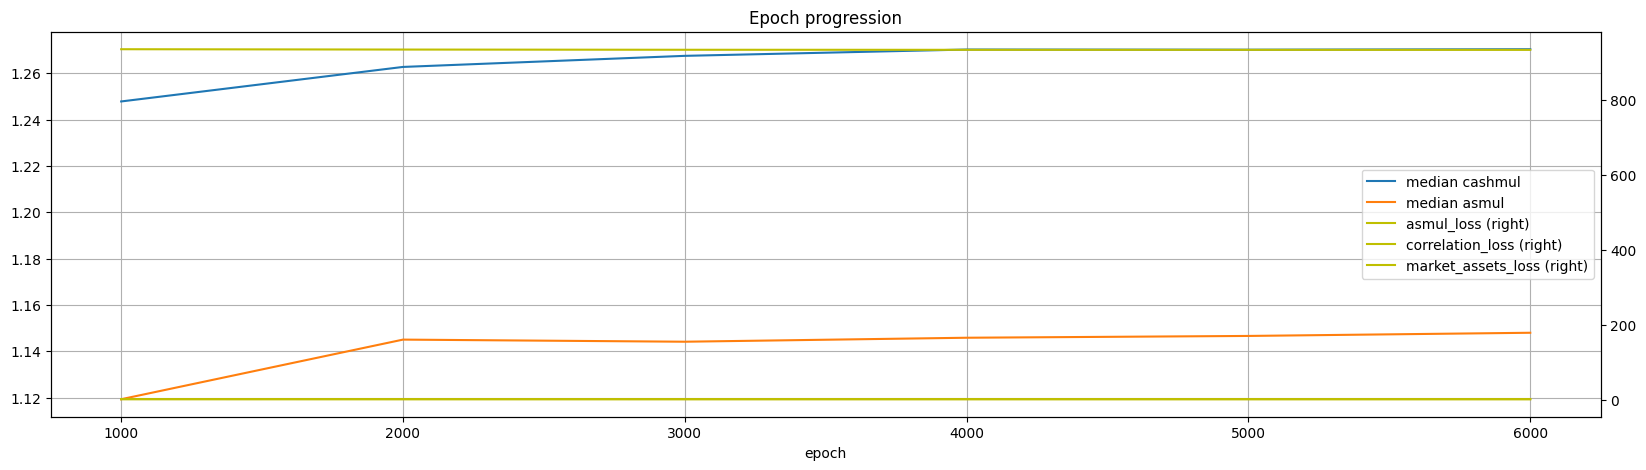

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.247795,1.119266,0.895999,934.385904,0.980026
2000,1.262694,1.144997,0.929136,933.504685,0.809121
3000,1.267480,1.144085,0.949204,932.928563,0.753275
4000,1.270204,1.145805,0.950756,932.802141,0.750953
5000,1.270136,1.146581,0.947279,932.734133,0.754350
6000,1.270339,1.147954,0.949603,932.676342,0.751152


In [10]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [11]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                         
0000001750 2013-01-01  2.189300     1.286500              0.149717  18.68   
           2013-02-01  2.189300     1.286500              0.149717  18.85   
           2013-03-01  2.189300     1.286500              0.149717  17.57   
           2013-04-01  2.217000     1.293000              0.163817  18.39   
           2013-05-01  2.217000     1.293000              0.163817  17.86   
...                         ...          ...                   ...    ...   
0001964333 2025-12-01  7.889037     7.066806              0.153871  65.24   
           2026-01-01  7.889037     7.066806              0.153871  62.31   
           2026-02-01  7.889037     7.066806              0.153871  65.48   
           2026-03-01  7.920626     7.065977              0.107933  64.44   
           2026-04-01  7.920626     7.065977              0.107933  62.29   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2013-01-01  1.022592 -1.358833  0.748820  
           2013-02-01  1.022592 -1.058136  0.793839  
           2013-03-01  1.022592 -0.949132  0.810159  
           2013-04-01  1.022592 -0.759280  0.849703  
           2013-05-01  1.022592 -0.719097  0.856286  
...                         ...       ...       ...  
0001964333 2025-12-01  1.480737  1.505181  4.846388  
           2026-01-01  1.480737  1.523593  4.849221  
           2026-02-01  1.480737  1.699207  4.876243  
           2026-03-01  1.480737  1.769745  4.853402  
           2026-04-01  1.480737  1.568282  4.831658  

[396817 rows x 7 columns]

In [12]:
%%time
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')

# The asset and cash multipliers are not available for the most recent snapshots,
# which are not part of the stock prices dataset.
# We use their latest available values in the model price formula for these recent snapshots. 
result = pd.concat([result.drop(columns=mul_columns),
                    result[mul_columns].groupby('cik',group_keys=False).apply(lambda x:x.interpolate())],
                   axis='columns')

result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(df):
    regressor = linear_model.LinearRegression().fit(X=df['model'].to_frame(), y=df[ml_label])
    return pd.Series({'hype':regressor.coef_[0], 'bias':regressor.intercept_})

result = result.merge(result[['model',ml_label]].dropna().groupby(by=['ticker','cik']).apply(line_fit),
                     left_index=True, right_index=True, how='inner')

result['model_price'] = result['model'] * result['hype'] + result['bias']

# We use the scaled ratio of model price to actual price as overvaluation metric.
result['overvaluation'] = result['model_price'] / result['price']
def interpolate_and_scale(df):
    df['overvaluation'] = -1 * preprocessing.RobustScaler().fit_transform(df['overvaluation'].to_frame())
    return df
result = result.groupby('cik',group_keys=False).apply(interpolate_and_scale)

result

CPU times: user 17.5 s, sys: 84 ms, total: 17.6 s
Wall time: 17.6 s


Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-06-20 0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001958086 CLB    2026-03-31   0.587728     0.318842   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  \
snapshot   cik        ticker date                                      
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68   
           0000001800 ABT    2012-09-30              9.212610  31.43   
           0000002098 ACU    2012-09-30              0.001128  11.04   
           0000002488 AMD    2012-09-29              0.135000   2.40   
           0000002809 AEM    2012-09-30              0.722071  52.46   
...                                                       ...    ...   
2026-06-20 0001952073 MSGE   2026-03-31              0.341042    NaN   
           0001953366 STHO   2026-03-31             -0.013730    NaN   
           0001955520 KNF    2026-03-31              0.345202    NaN   
           0001958086 CLB    2026-03-31              0.034336    NaN   
           0001964333 BHRB   2026-03-31              0.096788    NaN   

                                            asmul   cashmul      model  \
snapshot   cik        ticker date                                        
2013-01-01 0000001750 AIR    2012-11-30  1.022592 -1.358833   0.748820   
           0000001800 ABT    2012-09-30  0.990470 -1.358833  13.892935   
           0000002098 ACU    2012-09-30  0.982721 -1.358833   0.027676   
           0000002488 AMD    2012-09-29  0.214601 -1.358833  -2.816704   
           0000002809 AEM    2012-09-30  0.454676 -1.358833  -0.436964   
...                                           ...       ...        ...   
2026-06-20 0001952073 MSGE   2026-03-31  1.314429  1.568282   1.198279   
           0001953366 STHO   2026-03-31  1.045214  1.568282   0.239075   
           0001955520 KNF    2026-03-31  0.745343  1.568282   1.128453   
           0001958086 CLB    2026-03-31  1.856624  1.568282   0.826196   
           0001964333 BHRB   2026-03-31  1.480737  1.568282   4.827441   

                                               hype       bias  model_price  \
snapshot   cik        ticker date                                             
2013-01-01 0000001750 AIR    2012-11-30  100.633197 -66.915486     8.440630   
           0000001800 ABT    2012-09-30    2.262394  -6.664771    24.766523   
           0000002098 ACU    2012-09-30  268.825579   7.316567    14.756611   
           0000002488 AMD    2012-09-29   12.465901  49.147598    14.034840   
           0000002809 AEM    2012-09-30   25.531407  24.125052    12.968742   
...                                             ...        ...          ...   
2026-06-20 0001952073 MSGE   2026-03-31   53.583747   6.432481    70.640765   
           0001953366 STHO   2026-03-31   22.364412   2.542109     7.888889   
           0001955520 KNF    2026-03-31   61.308597  17.151069    86.334959   
           0001958086 CLB    2026-03-31  -39.575847  49.369774    16.672361   
           0001964333 BHRB   2026-03-31    2.501031  50.224038    62.297615   

                                         overvaluation  
snapshot   cik        ticker date                       
2013-01-01 0000001750 AIR    2012-11-30       1.988039  
           0000001800 ABT    2012-09-30       1.203897  
           00000

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

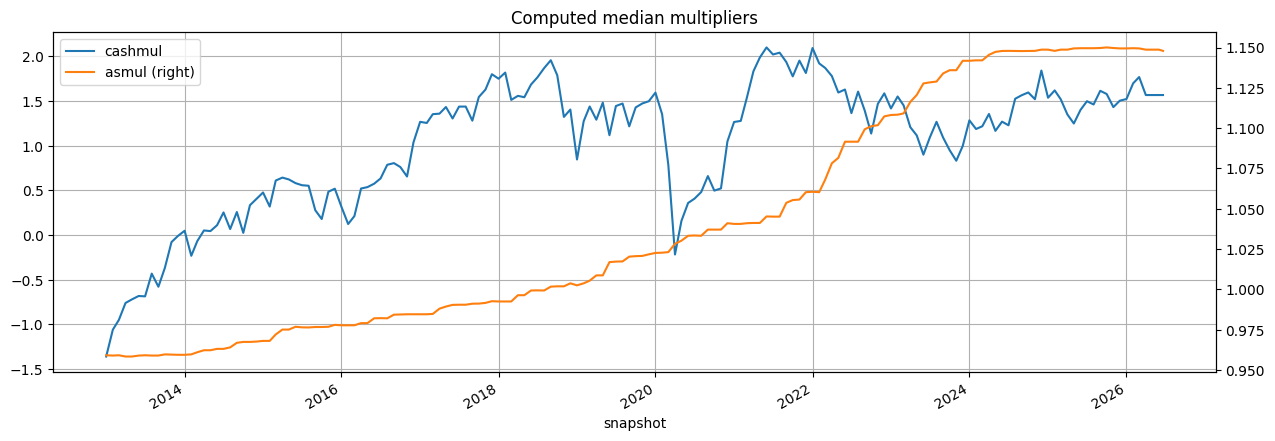

Median asset_multiplier per cik: 1.148719072341919
Median asset_multiplier per snapshot: 1.020606279373169


In [13]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

Let's examine the distribution of the achieved correlations:

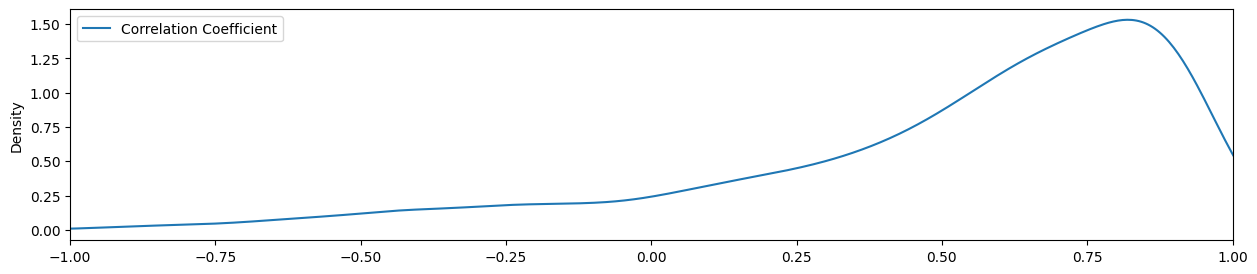

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().unstack().sum(axis='columns')/2 - 1
model_corr = model_corr.rename('Correlation Coefficient').to_frame()
model_corr.plot.density(bw_method=0.2,figsize=(15,3),xlim=(-1,1))
plt.show()

In [15]:
# Reality check for our fair price calculations:
# compute their correlation with the actual prices
result[['price','model_price']].dropna().corr()

,price,model_price
price,1.000000,0.898665
model_price,0.898665,1.000000


In [16]:
# We can now output the results for later use in other models/notebooks/datasets
result.to_csv('/kaggle/working/pricing_model.csv.gz')

The [Monthly US Stock Prices](https://www.kaggle.com/datasets/vladosht/monthly-us-stock-prices) dataset is updated a few times annually, which means the stock prices used in this notebook are quite outdated most of the time. Here we attempt to obtain delayed, but still recent prices. This is not reliable, as it uses a free online service. If it works though, the plots below will be more up-to-date.

In [17]:
def get_dataframe_from_api(endpoint):
    r = requests.get(api_url.format(endpoint))
    r.raise_for_status()
    return pd.DataFrame(r.json())[['dateStamp','code','name','close','volume','change']]

try:
    api_url = UserSecretsClient().get_secret("api_url")
    api_data = pd.concat([get_dataframe_from_api(exchange) for exchange in ['NASDAQ','NYSE']])
except:
    api_data = None
    print('Failed to fetch recent prices.')

In [18]:
if api_data is not None:
    recent_prices = api_data.rename(columns={'dateStamp':'snapshot','close':'price'})
    recent_prices['ticker'] = recent_prices['code'].str.upper().str.strip()
    recent_prices = recent_prices[recent_prices['ticker'].isin(result.index.get_level_values('ticker').unique())]
    recent_prices = recent_prices.sort_values(['ticker','snapshot']).drop_duplicates(subset=['ticker'],keep='last')
    recent_prices = recent_prices[(recent_prices['price']>0.005)&(recent_prices['volume']>0)&(recent_prices['change'].abs()>0.0)]
    recent_prices = recent_prices[recent_prices['snapshot'] == recent_prices['snapshot'].value_counts().index[0]]
    recent_prices = recent_prices[['snapshot','ticker','price','name']].set_index('ticker')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

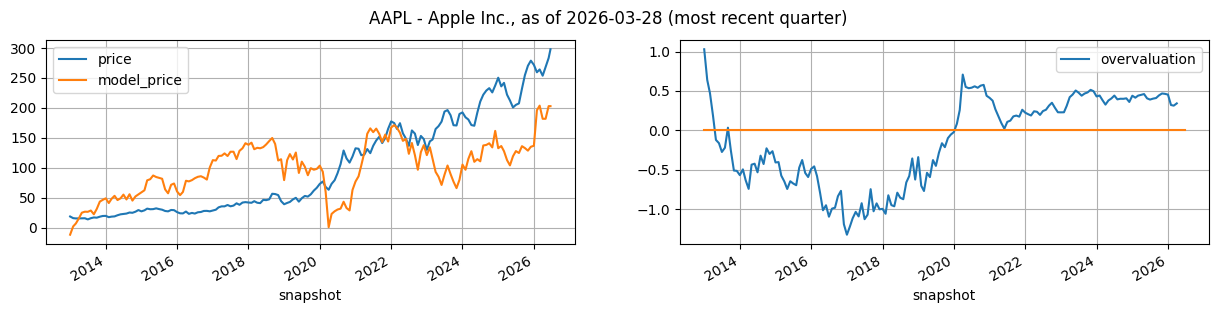

AAPL(0000320193) model_price = 0.803943 * (0.945222 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -43.070467


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-27,379.297,291.107,135.472,259.48,0.945222,1.699207,297.607924,0.803943,-43.070467,196.189289,0.321942
2026-03-01,2025-12-27,379.297,291.107,135.472,264.18,0.945222,1.769745,307.163790,0.803943,-43.070467,203.871659,0.313778
2026-04-01,2025-12-27,379.297,291.107,135.472,253.79,0.945222,1.568282,279.871293,0.803943,-43.070467,181.930052,0.342435
2026-05-01,2025-12-27,379.297,291.107,135.472,NaN,0.945222,1.568282,279.871293,0.803943,-43.070467,181.930052,NaN
2026-06-01,2026-03-28,371.082,264.591,140.222,NaN,0.945222,1.568282,306.071634,0.803943,-43.070467,202.993628,NaN
2026-06-20,2026-03-28,371.082,264.591,140.222,297.89,0.945222,1.568282,306.071634,0.803943,-43.070467,202.993628,NaN


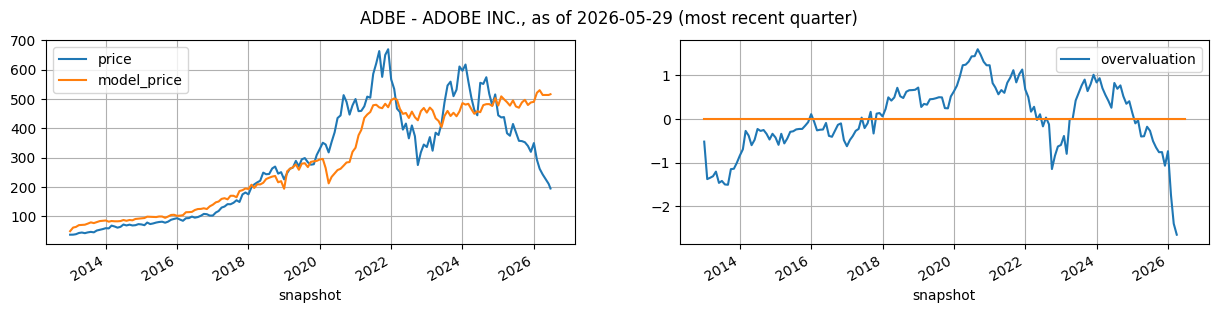

ADBE(0000796343) model_price = 12.328152 * (1.703202 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -87.610812


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-28,29.496,17.873,10.031,293.25,1.703202,1.699207,49.409389,12.328152,-87.610812,521.515622,-1.744698
2026-03-01,2025-11-28,29.496,17.873,10.031,262.41,1.703202,1.769745,50.116951,12.328152,-87.610812,530.238558,-2.393605
2026-04-01,2026-02-27,29.704,18.271,10.507,243.08,1.703202,1.568282,48.798852,12.328152,-87.610812,513.988826,-2.644958
2026-05-01,2026-02-27,29.704,18.271,10.507,NaN,1.703202,1.568282,48.798852,12.328152,-87.610812,513.988826,NaN
2026-06-01,2026-02-27,29.704,18.271,10.507,NaN,1.703202,1.568282,48.798852,12.328152,-87.610812,513.988826,NaN
2026-06-20,2026-05-29,29.933,18.415,10.481,195.15,1.703202,1.568282,49.004110,12.328152,-87.610812,516.519277,NaN


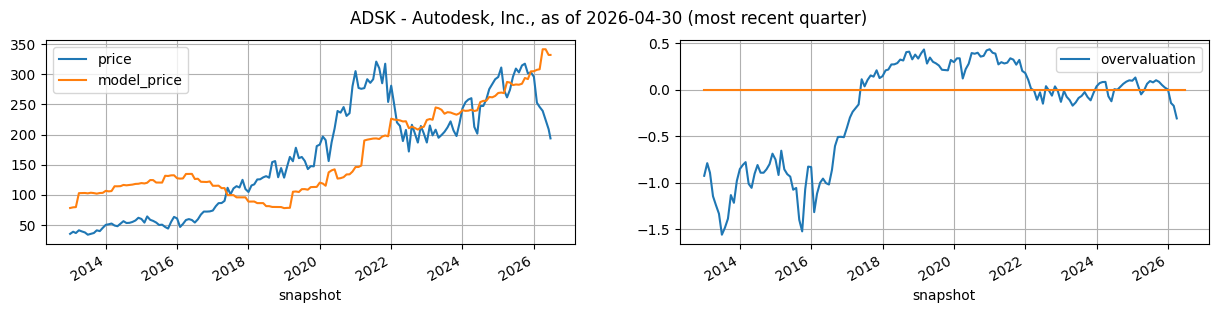

ADSK(0000769397) model_price = 6.195640 * (5.077254 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -15.992794


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-31,11.198,8.305,2.155,252.87,5.077254,1.699207,52.211879,6.19564,-15.992794,307.493210,-0.144038
2026-03-01,2025-10-31,11.198,8.305,2.155,245.87,5.077254,1.769745,52.363888,6.19564,-15.992794,308.435000,-0.174218
2026-04-01,2026-01-31,12.467,9.422,2.452,239.40,5.077254,1.568282,57.721552,6.19564,-15.992794,341.629155,-0.309657
2026-05-01,2026-01-31,12.467,9.422,2.452,NaN,5.077254,1.568282,57.721552,6.19564,-15.992794,341.629155,NaN
2026-06-01,2026-04-30,11.932,8.743,2.781,NaN,5.077254,1.568282,56.200186,6.19564,-15.992794,332.203320,NaN
2026-06-20,2026-04-30,11.932,8.743,2.781,193.76,5.077254,1.568282,56.200186,6.19564,-15.992794,332.203320,NaN


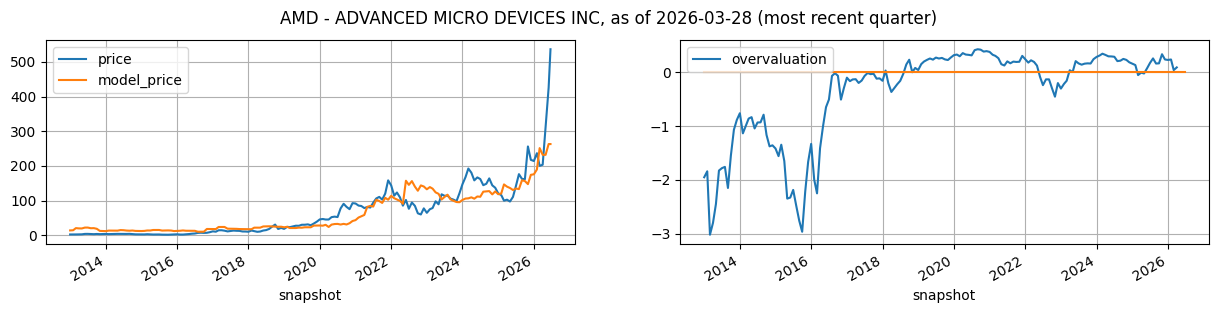

AMD(0000002488) model_price = 12.465901 * (0.214601 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +49.147598


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-27,76.891,16.101,6.408,236.73,0.214601,1.699207,11.288374,12.465901,49.147598,189.867353,0.240821
2026-03-01,2025-12-27,76.926,13.927,7.709,200.21,0.214601,1.769745,16.224328,12.465901,49.147598,251.398460,0.043694
2026-04-01,2025-12-27,76.926,13.927,7.709,203.43,0.214601,1.568282,14.671255,12.465901,49.147598,232.038011,0.093688
2026-05-01,2025-12-27,76.926,13.927,7.709,NaN,0.214601,1.568282,14.671255,12.465901,49.147598,232.038011,NaN
2026-06-01,2026-03-28,79.642,15.180,9.725,NaN,0.214601,1.568282,17.162768,12.465901,49.147598,263.096959,NaN
2026-06-20,2026-03-28,79.642,15.180,9.725,536.44,0.214601,1.568282,17.162768,12.465901,49.147598,263.096959,NaN


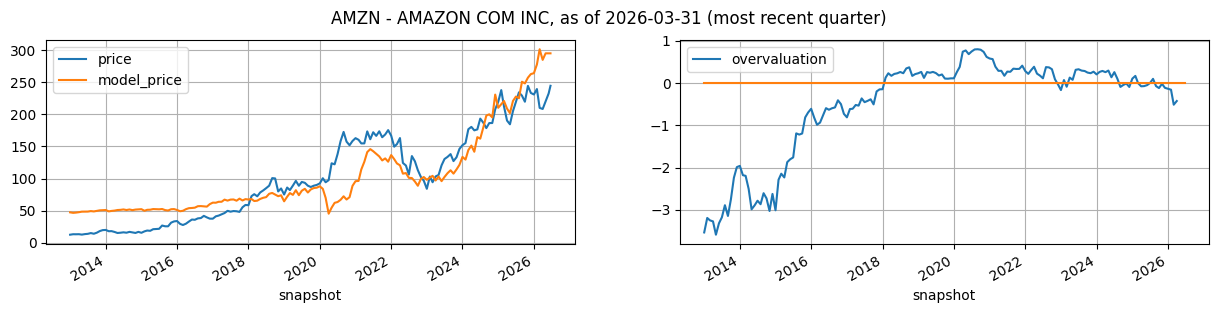

AMZN(0001018724) model_price = 0.567707 * (0.724532 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +50.584444


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,727.921,358.290,135.738750,239.30,0.724532,1.699207,399.760437,0.567707,50.584444,277.531092,-0.156869
2026-03-01,2025-12-31,818.042,406.977,144.561750,210.00,0.724532,1.769745,441.558141,0.567707,50.584444,301.259925,-0.511994
2026-04-01,2025-12-31,818.042,406.977,144.561750,208.27,0.724532,1.568282,412.434403,0.567707,50.584444,284.726185,-0.424805
2026-05-01,2026-03-31,916.630,474.716,153.635917,NaN,0.724532,1.568282,430.356438,0.567707,50.584444,294.900644,NaN
2026-06-01,2026-03-31,916.630,474.716,153.635917,NaN,0.724532,1.568282,430.356438,0.567707,50.584444,294.900644,NaN
2026-06-20,2026-03-31,916.630,474.716,153.635917,244.37,0.724532,1.568282,430.356438,0.567707,50.584444,294.900644,NaN


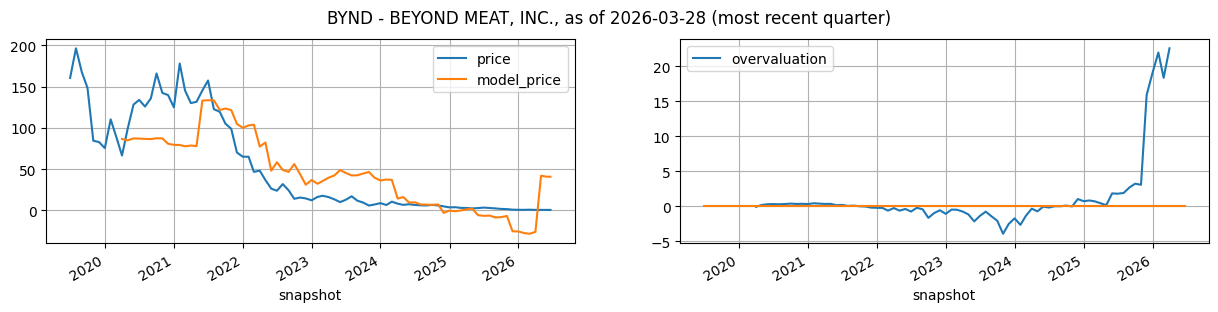

BYND(0001655210) model_price = 88.775378 * (1.750493 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +21.409684


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-27,0.599669,1.383734,-0.127090,0.7630,1.750493,1.699207,-0.549970,88.775378,21.409684,-27.414100,21.986448
2026-03-01,2025-09-27,0.599669,1.383734,-0.127090,0.9460,1.750493,1.769745,-0.558935,88.775378,21.409684,-28.209937,18.365745
2026-04-01,2025-09-27,0.599669,1.383734,-0.127090,0.7020,1.750493,1.568282,-0.533331,88.775378,21.409684,-25.936947,22.589704
2026-05-01,2025-12-31,0.614747,0.615744,-0.144931,NaN,1.750493,1.568282,0.233074,88.775378,21.409684,42.100877,NaN
2026-06-01,2026-03-28,0.579464,0.600547,-0.123813,NaN,1.750493,1.568282,0.219627,88.775378,21.409684,40.907145,NaN
2026-06-20,2026-03-28,0.579464,0.600547,-0.123813,0.7092,1.750493,1.568282,0.219627,88.775378,21.409684,40.907145,NaN


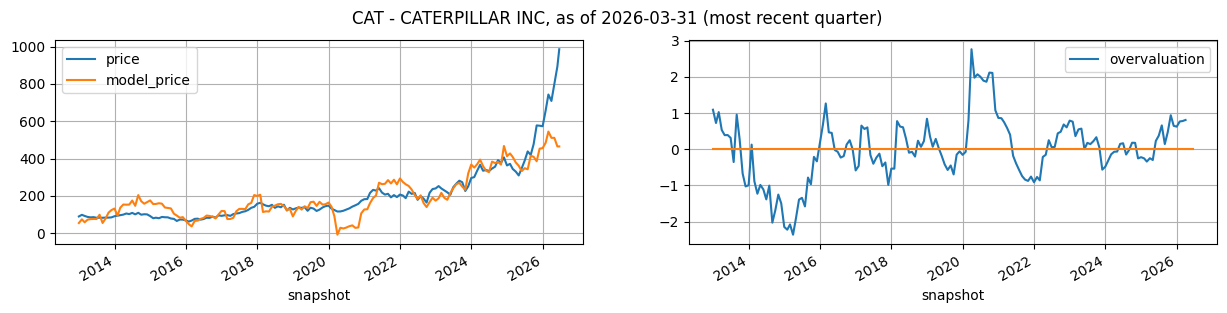

CAT(0000018230) model_price = 14.234925 * (1.489616 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -741.917422


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,93.722,73.063,11.541,657.36,1.489616,1.699207,86.157298,14.234925,-741.917422,484.525299,0.767752
2026-03-01,2025-12-31,98.585,77.267,11.739,742.83,1.489616,1.769745,90.361782,14.234925,-741.917422,544.375815,0.778225
2026-04-01,2025-12-31,98.585,77.267,11.739,708.46,1.489616,1.568282,87.996817,14.234925,-741.917422,510.710707,0.807800
2026-05-01,2025-12-31,98.585,77.267,11.739,NaN,1.489616,1.568282,87.996817,14.234925,-741.917422,510.710707,NaN
2026-06-01,2026-03-31,95.550,76.890,12.320,NaN,1.489616,1.568282,84.764005,14.234925,-741.917422,464.691881,NaN
2026-06-20,2026-03-31,95.550,76.890,12.320,985.43,1.489616,1.568282,84.764005,14.234925,-741.917422,464.691881,NaN


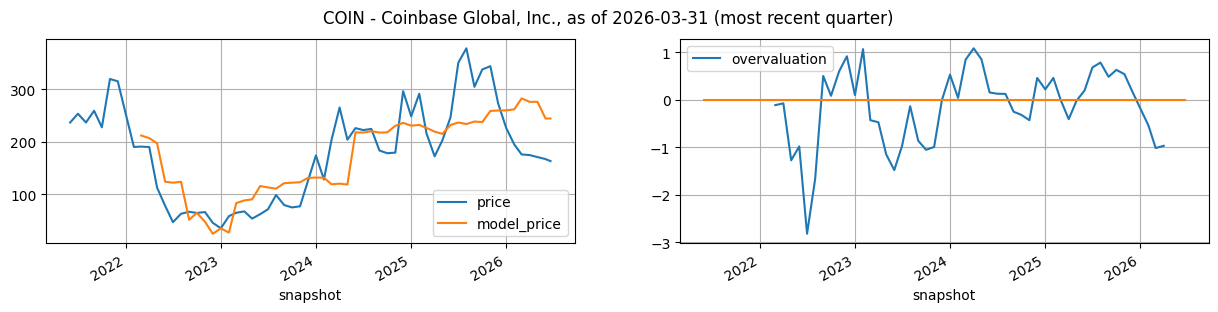

COIN(0001679788) model_price = 13.353109 * (1.016921 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +20.885025


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,31.351367,15.328143,0.872941,194.74,1.016921,1.699207,18.037022,13.353109,20.885025,261.735346,-0.535030
2026-03-01,2025-12-31,29.671832,14.878774,2.426383,175.85,1.016921,1.769745,19.589208,13.353109,20.885025,282.461850,-1.012953
2026-04-01,2025-12-31,29.671832,14.878774,2.426383,174.61,1.016921,1.568282,19.100383,13.353109,20.885025,275.934522,-0.965615
2026-05-01,2025-12-31,29.671832,14.878774,2.426383,NaN,1.016921,1.568282,19.100383,13.353109,20.885025,275.934522,NaN
2026-06-01,2026-03-31,28.848792,15.368219,1.756433,NaN,1.016921,1.568282,16.723301,13.353109,20.885025,244.193083,NaN
2026-06-20,2026-03-31,28.848792,15.368219,1.756433,163.23,1.016921,1.568282,16.723301,13.353109,20.885025,244.193083,NaN


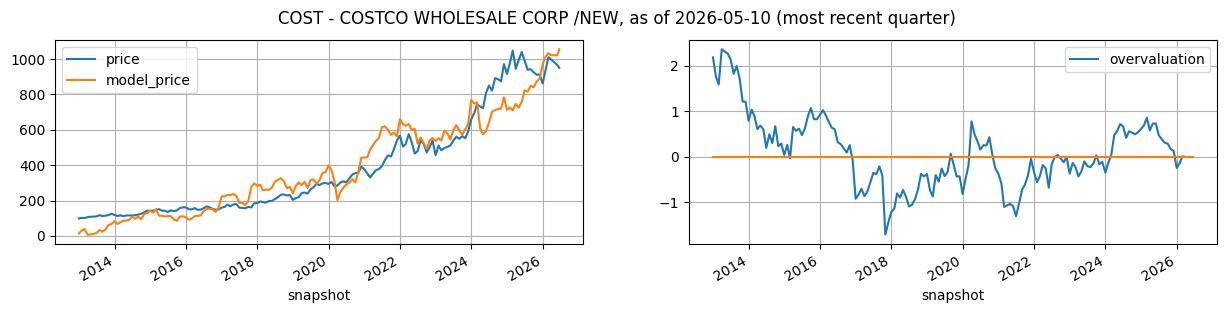

COST(0000909832) model_price = 17.384633 * (1.189734 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -220.686179


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-23,82.790,52.487,14.763,940.25,1.189734,1.699207,71.096431,17.384633,-220.686179,1015.299152,-0.136942
2026-03-01,2025-11-23,82.790,52.487,14.763,1010.79,1.189734,1.769745,72.137777,17.384633,-220.686179,1033.402571,0.004385
2026-04-01,2026-02-15,83.639,51.552,15.011,996.43,1.189734,1.568282,71.497607,17.384633,-220.686179,1022.273456,-0.004385
2026-05-01,2026-02-15,83.639,51.552,15.011,NaN,1.189734,1.568282,71.497607,17.384633,-220.686179,1022.273456,NaN
2026-06-01,2026-02-15,83.639,51.552,15.011,NaN,1.189734,1.568282,71.497607,17.384633,-220.686179,1022.273456,NaN
2026-06-20,2026-05-10,86.430,52.921,15.000,951.27,1.189734,1.568282,73.431902,17.384633,-220.686179,1055.900466,NaN


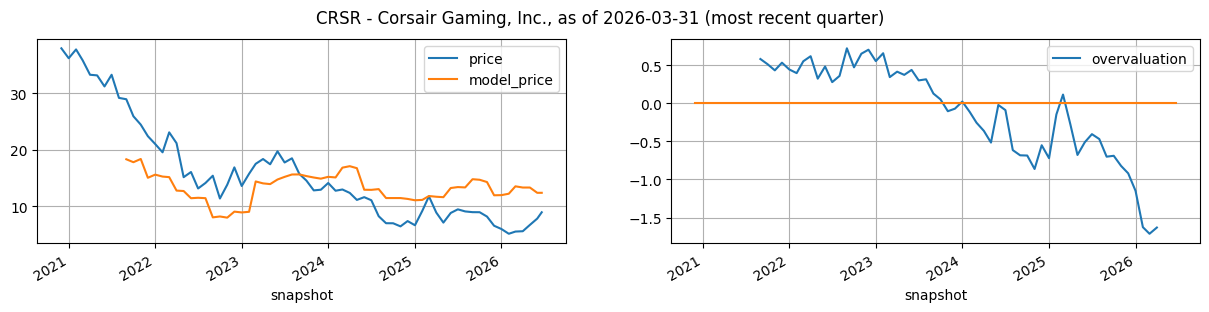

CRSR(0001743759) model_price = 21.188259 * (1.986920 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -28.010618


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,1.198499,0.598269,0.067507,5.10,1.98692,1.699207,1.897760,21.188259,-28.010618,12.199621,-1.625549
2026-03-01,2025-12-31,1.253784,0.620227,0.050121,5.49,1.98692,1.769745,1.959642,21.188259,-28.010618,13.510790,-1.711925
2026-04-01,2025-12-31,1.253784,0.620227,0.050121,5.55,1.98692,1.568282,1.949545,21.188259,-28.010618,13.296842,-1.630243
2026-05-01,2025-12-31,1.253784,0.620227,0.050121,NaN,1.98692,1.568282,1.949545,21.188259,-28.010618,13.296842,NaN
2026-06-01,2026-03-31,1.177340,0.529698,0.061099,NaN,1.98692,1.568282,1.905402,21.188259,-28.010618,12.361539,NaN
2026-06-20,2026-03-31,1.177340,0.529698,0.061099,8.91,1.98692,1.568282,1.905402,21.188259,-28.010618,12.361539,NaN


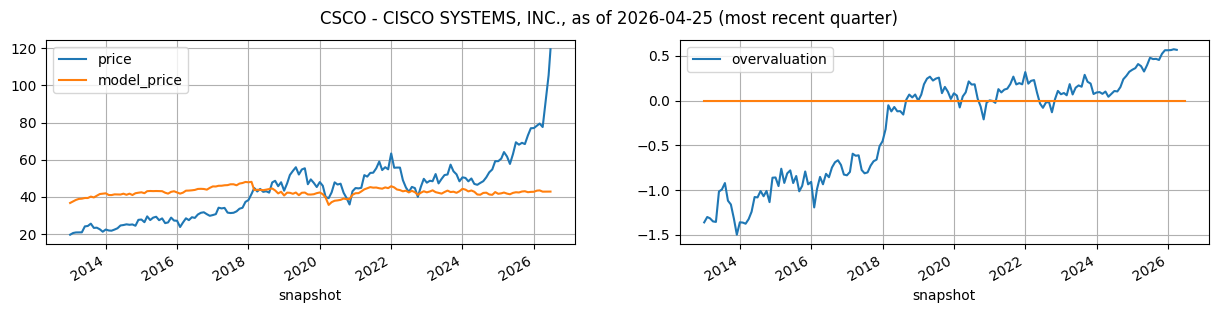

CSCO(0000858877) model_price = 0.250421 * (0.757833 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.113482


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-25,121.102,74.229,13.744,78.32,0.757833,1.699207,40.900045,0.250421,33.113482,43.355713,0.564121
2026-03-01,2026-01-24,123.371,75.648,13.325,79.46,0.757833,1.769745,41.428514,0.250421,33.113482,43.488053,0.573307
2026-04-01,2026-01-24,123.371,75.648,13.325,77.59,0.757833,1.568282,38.744030,0.250421,33.113482,42.815802,0.566683
2026-05-01,2026-01-24,123.371,75.648,13.325,NaN,0.757833,1.568282,38.744030,0.250421,33.113482,42.815802,NaN
2026-06-01,2026-04-25,125.546,76.685,13.025,NaN,0.757833,1.568282,38.884833,0.250421,33.113482,42.851062,NaN
2026-06-20,2026-04-25,125.546,76.685,13.025,119.44,0.757833,1.568282,38.884833,0.250421,33.113482,42.851062,NaN


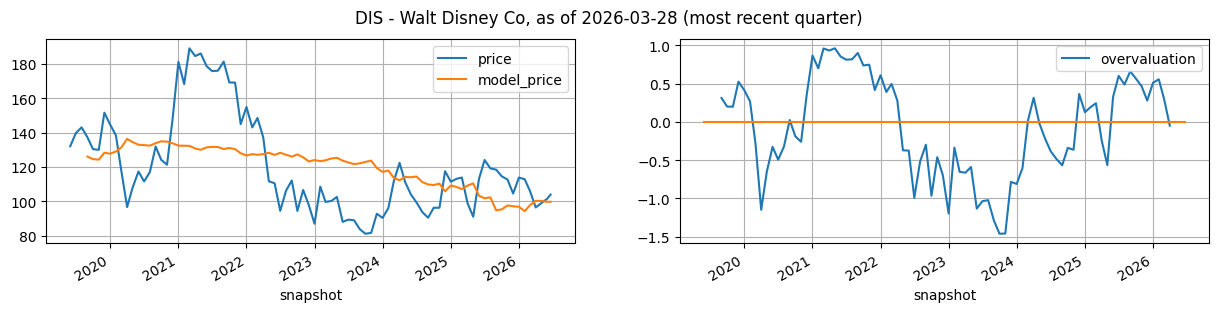

DIS(0001744489) model_price = -0.808680 * (1.050499 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +216.000023


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-27,197.514,87.645,18.101,112.80,1.050499,1.699207,150.600693,-0.80868,216.000023,94.212301,0.556322
2026-03-01,2025-12-27,202.089,93.613,15.631,106.04,1.050499,1.769745,146.344260,-0.80868,216.000023,97.654393,0.302517
2026-04-01,2025-12-27,202.089,93.613,15.631,96.38,1.050499,1.568282,143.195203,-0.80868,216.000023,100.200971,-0.049072
2026-05-01,2025-12-27,202.089,93.613,15.631,NaN,1.050499,1.568282,143.195203,-0.80868,216.000023,100.200971,NaN
2026-06-01,2026-03-28,205.217,96.509,15.792,NaN,1.050499,1.568282,143.837659,-0.80868,216.000023,99.681430,NaN
2026-06-20,2026-03-28,205.217,96.509,15.792,103.87,1.050499,1.568282,143.837659,-0.80868,216.000023,99.681430,NaN


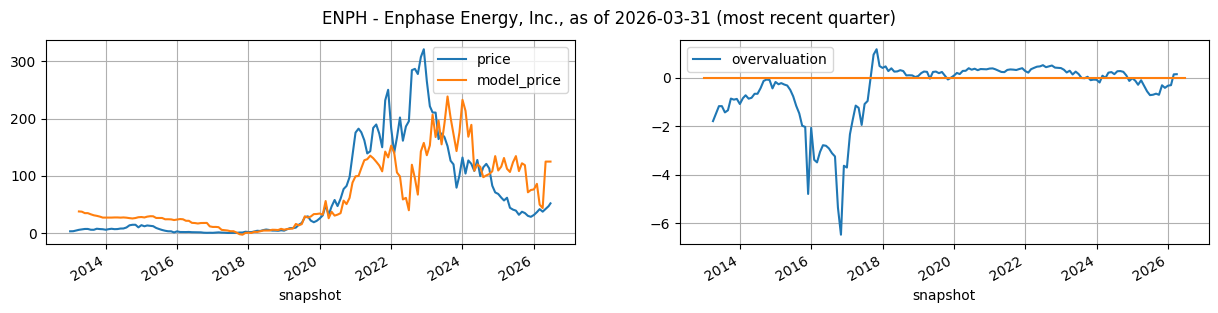

ENPH(0001463101) model_price = 215.605414 * (0.650745 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.875220


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,3.320488,2.325466,0.256253,36.98,0.650745,1.699207,0.270752,215.605414,27.87522,86.250814,-0.305752
2026-03-01,2025-12-31,3.509792,2.422769,0.136540,42.27,0.650745,1.769745,0.102852,215.605414,27.87522,50.050592,0.139739
2026-04-01,2025-12-31,3.509792,2.422769,0.136540,37.81,0.650745,1.568282,0.075344,215.605414,27.87522,44.119792,0.146407
2026-05-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.650745,1.568282,0.450546,215.605414,27.87522,125.015289,NaN
2026-06-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.650745,1.568282,0.450546,215.605414,27.87522,125.015289,NaN
2026-06-20,2026-03-31,2.723923,1.621571,0.190997,52.29,0.650745,1.568282,0.450546,215.605414,27.87522,125.015289,NaN


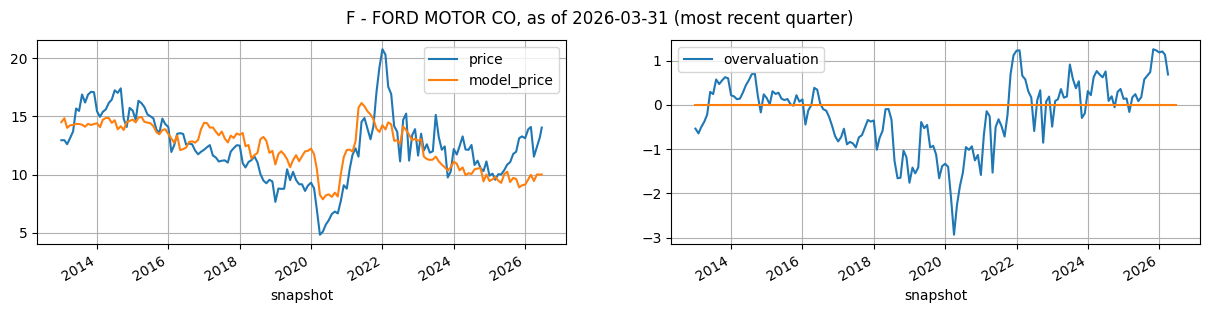

F(0000037996) model_price = 0.124017 * (0.007344 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +36.445662


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,300.990,253.598,20.426,13.880,0.007344,1.699207,-216.679465,0.124017,36.445662,9.573746,1.206052
2026-03-01,2025-12-31,289.160,253.208,21.282,14.090,0.007344,1.769745,-213.420645,0.124017,36.445662,9.977895,1.131361
2026-04-01,2025-12-31,289.160,253.208,21.282,11.540,0.007344,1.568282,-217.708165,0.124017,36.445662,9.446170,0.683276
2026-05-01,2026-03-31,282.434,244.981,18.919,NaN,0.007344,1.568282,-213.236414,0.124017,36.445662,10.000743,NaN
2026-06-01,2026-03-31,282.434,244.981,18.919,NaN,0.007344,1.568282,-213.236414,0.124017,36.445662,10.000743,NaN
2026-06-20,2026-03-31,282.434,244.981,18.919,14.038,0.007344,1.568282,-213.236414,0.124017,36.445662,10.000743,NaN


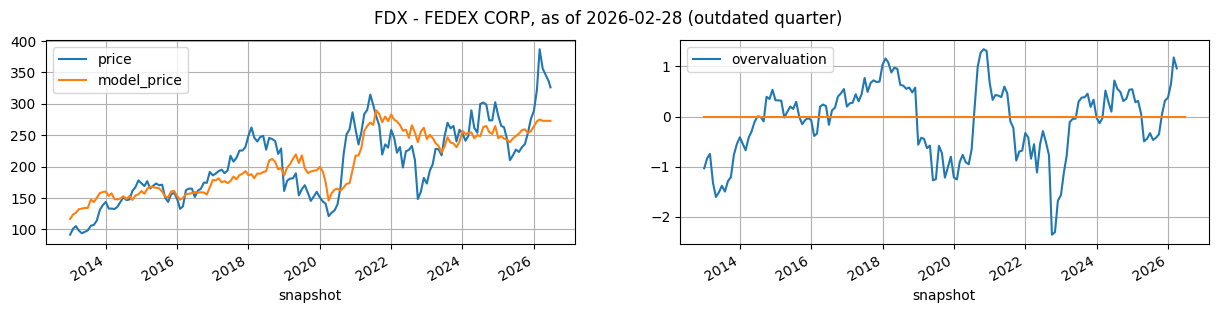

FDX(0001048911) model_price = 5.444393 * (0.931427 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +76.281490


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-30,89.181,61.041,8.198,322.25,0.931427,1.699207,35.954680,5.444393,76.28149,272.032893,0.656799
2026-03-01,2025-11-30,89.181,61.041,8.198,387.00,0.931427,1.769745,36.532947,5.444393,76.28149,275.181205,1.180464
2026-04-01,2026-02-28,94.733,64.929,8.179,356.18,0.931427,1.568282,36.134844,5.444393,76.28149,273.013776,0.962340
2026-05-01,2026-02-28,94.733,64.929,8.179,NaN,0.931427,1.568282,36.134844,5.444393,76.28149,273.013776,NaN
2026-06-01,2026-02-28,94.733,64.929,8.179,NaN,0.931427,1.568282,36.134844,5.444393,76.28149,273.013776,NaN
2026-06-20,2026-02-28,94.733,64.929,8.179,326.32,0.931427,1.568282,36.134844,5.444393,76.28149,273.013776,NaN


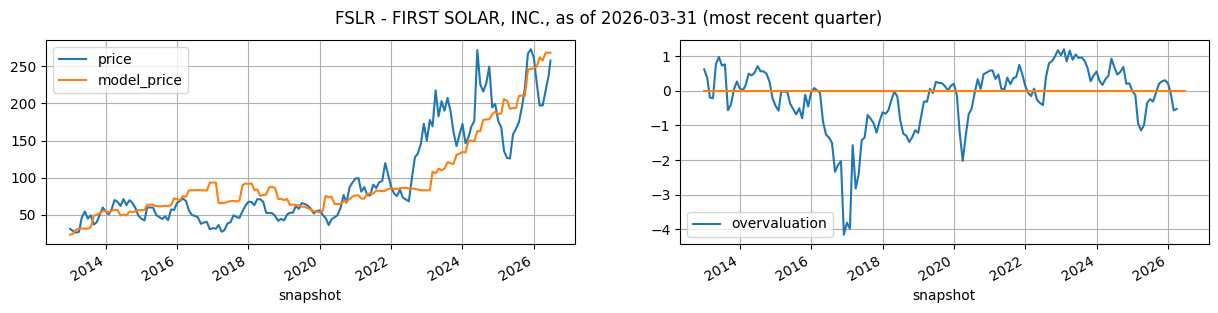

FSLR(0001274494) model_price = 10.419479 * (2.716858 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -113.598633


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,13.459309,4.443997,1.626208,225.52,2.716857,1.699207,34.886291,10.419479,-113.598633,249.898332,-0.115122
2026-03-01,2025-12-31,13.321310,3.783317,2.057105,197.20,2.716857,1.769745,36.049334,10.419479,-113.598633,262.016632,-0.568001
2026-04-01,2025-12-31,13.321310,3.783317,2.057105,197.26,2.716857,1.568282,35.634905,10.419479,-113.598633,257.698497,-0.522228
2026-05-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.716857,1.568282,36.643137,10.419479,-113.598633,268.203748,NaN
2026-06-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.716857,1.568282,36.643137,10.419479,-113.598633,268.203748,NaN
2026-06-20,2026-03-31,13.351097,3.472529,2.450221,257.65,2.716857,1.568282,36.643137,10.419479,-113.598633,268.203748,NaN


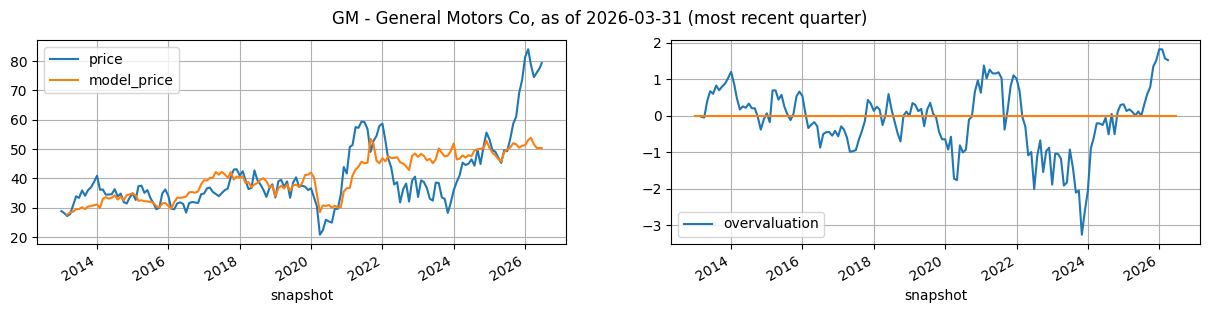

GM(0001467858) model_price = 0.400065 * (0.870968 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +24.860824


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,281.284,220.165,26.867,84.000,0.870968,1.699207,70.476854,0.400065,24.860824,53.056159,1.823494
2026-03-01,2025-12-31,281.284,220.165,26.867,78.710,0.870968,1.769745,72.371987,0.400065,24.860824,53.814335,1.573760
2026-04-01,2025-12-31,281.284,220.165,26.867,74.500,0.870968,1.568282,66.959300,0.400065,24.860824,51.648908,1.527873
2026-05-01,2026-03-31,280.974,218.315,23.756,NaN,0.870968,1.568282,63.660374,0.400065,24.860824,50.329122,NaN
2026-06-01,2026-03-31,280.974,218.315,23.756,NaN,0.870968,1.568282,63.660374,0.400065,24.860824,50.329122,NaN
2026-06-20,2026-03-31,280.974,218.315,23.756,79.305,0.870968,1.568282,63.660374,0.400065,24.860824,50.329122,NaN


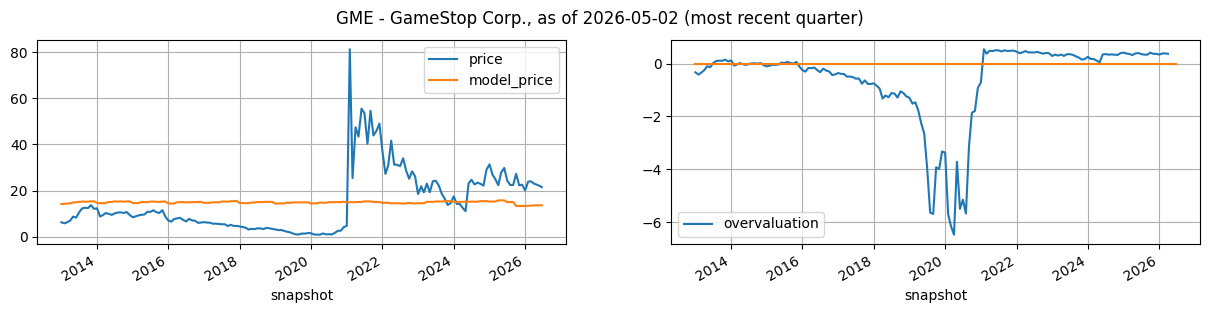

GME(0001326380) model_price = 0.662653 * (0.000353 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.235507


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-01,10.5507,5.2477,0.5835,23.880,0.000353,1.699207,-4.252487,0.662653,16.235507,13.417586,0.382462
2026-03-01,2025-11-01,10.5507,5.2477,0.5835,24.030,0.000353,1.769745,-4.211329,0.662653,16.235507,13.444860,0.383461
2026-04-01,2026-01-31,10.3884,4.9440,0.6148,23.040,0.000353,1.568282,-3.976152,0.662653,16.235507,13.600700,0.370490
2026-05-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.000353,1.568282,-3.976152,0.662653,16.235507,13.600700,NaN
2026-06-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.000353,1.568282,-3.976152,0.662653,16.235507,13.600700,NaN
2026-06-20,2026-05-02,10.9743,5.1322,0.7597,21.495,0.000353,1.568282,-3.936901,0.662653,16.235507,13.626710,NaN


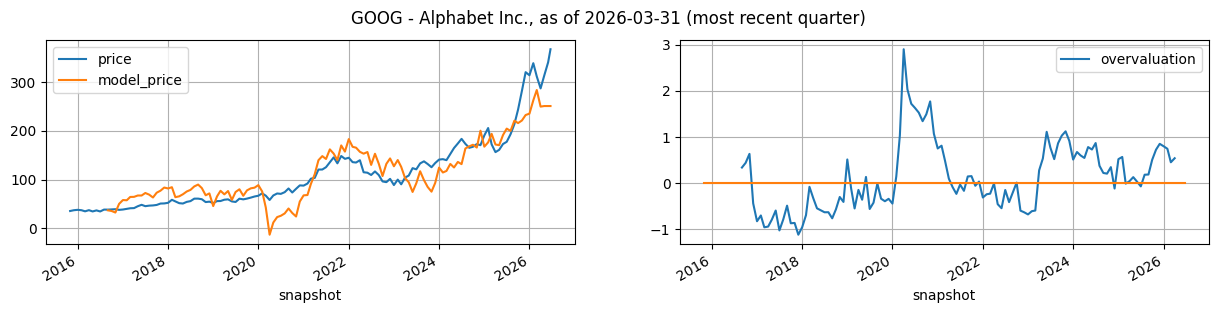

GOOG(0001652044) model_price = 1.024745 * (0.286970 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -5.757516


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,536.469,149.602,151.424,338.53,0.28697,1.699207,261.649282,1.024745,-5.757516,262.366218,0.744061
2026-03-01,2025-12-31,595.281,180.016,164.713,311.43,0.28697,1.769745,282.311784,1.024745,-5.757516,283.540008,0.450991
2026-04-01,2025-12-31,595.281,180.016,164.713,286.86,0.28697,1.568282,249.128329,1.024745,-5.757516,249.535436,0.538762
2026-05-01,2026-03-31,703.919,225.173,174.353,NaN,0.28697,1.568282,250.265426,1.024745,-5.757516,250.700671,NaN
2026-06-01,2026-03-31,703.919,225.173,174.353,NaN,0.28697,1.568282,250.265426,1.024745,-5.757516,250.700671,NaN
2026-06-20,2026-03-31,703.919,225.173,174.353,367.11,0.28697,1.568282,250.265426,1.024745,-5.757516,250.700671,NaN


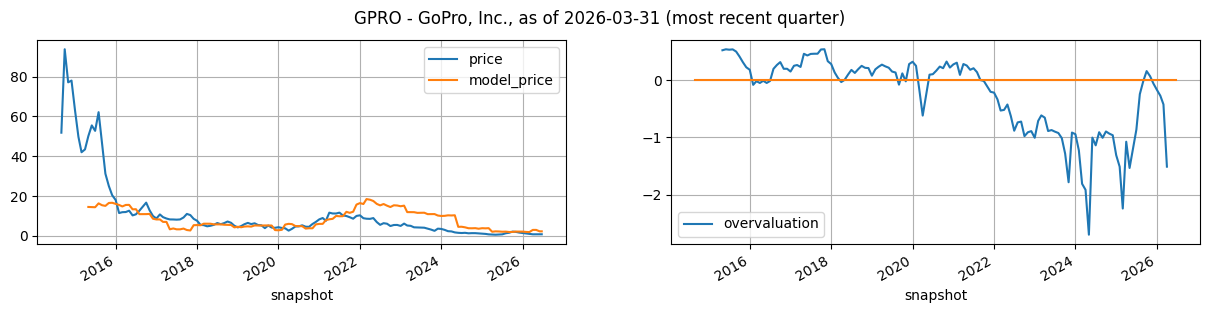

GPRO(0001500435) model_price = 15.329306 * (1.010950 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +2.235863


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,0.538608,0.458114,-0.061371,1.1600,1.01095,1.699207,-0.017890,15.329306,2.235863,1.961615,-0.274825
2026-03-01,2025-09-30,0.538608,0.458114,-0.061371,0.9680,1.01095,1.769745,-0.022219,15.329306,2.235863,1.895255,-0.426031
2026-04-01,2025-12-31,0.427983,0.351433,-0.020669,0.7700,1.01095,1.568282,0.048821,15.329306,2.235863,2.984262,-1.512655
2026-05-01,2025-12-31,0.427983,0.351433,-0.020669,NaN,1.01095,1.568282,0.048821,15.329306,2.235863,2.984262,NaN
2026-06-01,2026-03-31,0.381355,0.383224,-0.000101,NaN,1.01095,1.568282,0.002148,15.329306,2.235863,2.268795,NaN
2026-06-20,2026-03-31,0.381355,0.383224,-0.000101,0.7931,1.01095,1.568282,0.002148,15.329306,2.235863,2.268795,NaN


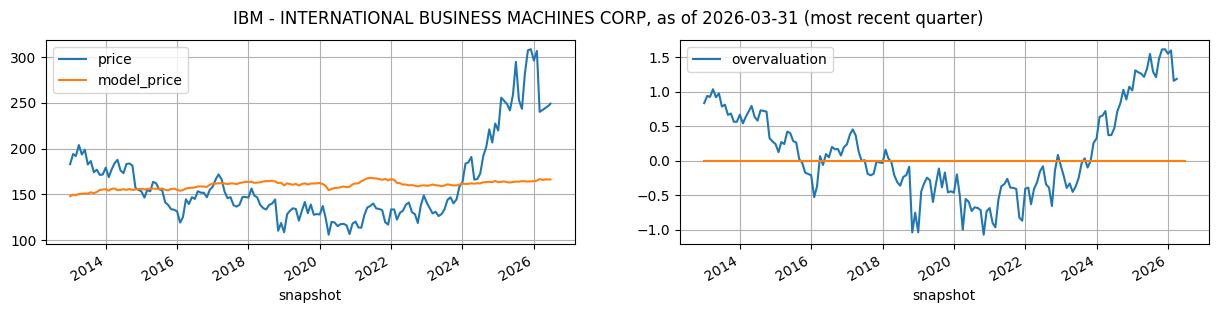

IBM(0000051143) model_price = 0.315987 * (0.994790 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +149.326565


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,146.312,118.407,13.483,306.70,0.99479,1.699207,50.053161,0.315987,149.326565,165.142715,1.597347
2026-03-01,2025-12-31,151.880,119.232,13.193,240.21,0.99479,1.769745,55.204985,0.315987,149.326565,166.770624,1.156819
2026-04-01,2025-12-31,151.880,119.232,13.193,242.39,0.99479,1.568282,52.547093,0.315987,149.326565,165.930765,1.184268
2026-05-01,2026-03-31,156.229,123.255,13.992,NaN,0.99479,1.568282,54.103494,0.315987,149.326565,166.422567,NaN
2026-06-01,2026-03-31,156.229,123.255,13.992,NaN,0.99479,1.568282,54.103494,0.315987,149.326565,166.422567,NaN
2026-06-20,2026-03-31,156.229,123.255,13.992,249.18,0.99479,1.568282,54.103494,0.315987,149.326565,166.422567,NaN


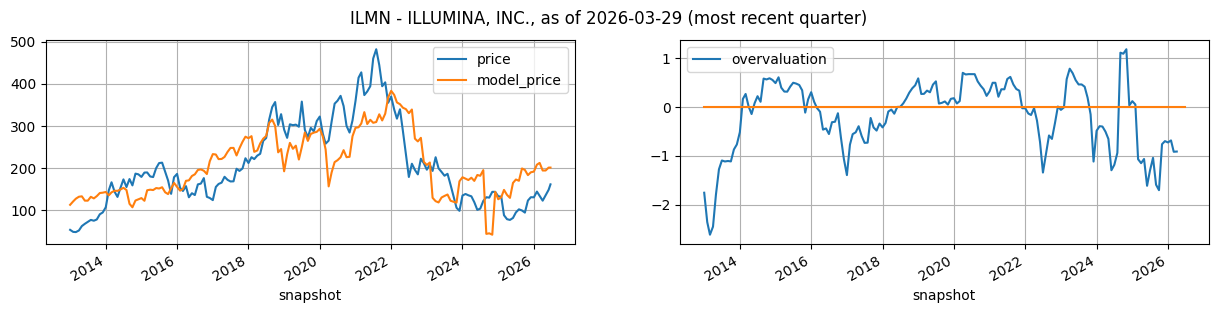

ILMN(0001110803) model_price = 83.023118 * (0.369972 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +175.714114


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-28,6.177,3.796,1.122,144.81,0.369972,1.699207,0.395827,83.023118,175.714114,208.576932,-0.681754
2026-03-01,2025-12-28,6.644,3.921,1.079,134.46,0.369972,1.769745,0.446648,83.023118,175.714114,212.796254,-0.913875
2026-04-01,2025-12-28,6.644,3.921,1.079,123.26,0.369972,1.568282,0.229271,83.023118,175.714114,194.748872,-0.909608
2026-05-01,2025-12-28,6.644,3.921,1.079,NaN,0.369972,1.568282,0.229271,83.023118,175.714114,194.748872,NaN
2026-06-01,2026-03-29,6.559,3.883,1.128,NaN,0.369972,1.568282,0.312669,83.023118,175.714114,201.672852,NaN
2026-06-20,2026-03-29,6.559,3.883,1.128,161.91,0.369972,1.568282,0.312669,83.023118,175.714114,201.672852,NaN


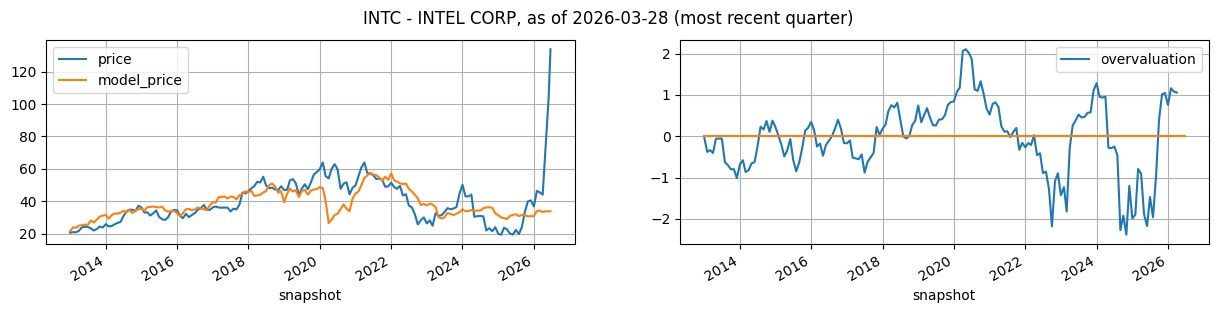

INTC(0000050863) model_price = 0.413758 * (0.430485 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +29.677297


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-27,211.429,97.148,9.697,46.47,0.430485,1.699207,10.346176,0.413758,29.677297,33.958108,1.160063
2026-03-01,2025-12-27,211.429,97.148,9.697,45.61,0.430485,1.769745,11.030179,0.413758,29.677297,34.241119,1.084946
2026-04-01,2025-12-27,211.429,97.148,9.697,44.13,0.430485,1.568282,9.076599,0.413758,29.677297,33.432810,1.059155
2026-05-01,2026-03-28,205.332,93.938,9.980,NaN,0.430485,1.568282,10.105757,0.413758,29.677297,33.858633,NaN
2026-06-01,2026-03-28,205.332,93.938,9.980,NaN,0.430485,1.568282,10.105757,0.413758,29.677297,33.858633,NaN
2026-06-20,2026-03-28,205.332,93.938,9.980,133.79,0.430485,1.568282,10.105757,0.413758,29.677297,33.858633,NaN


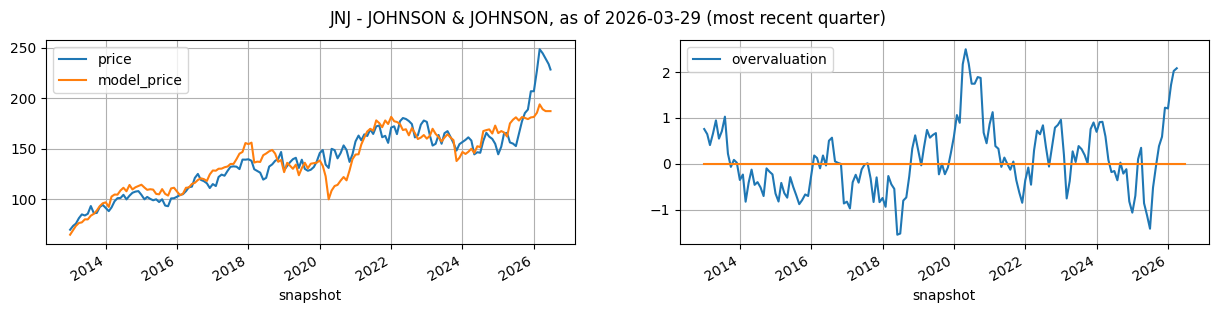

JNJ(0000200406) model_price = 0.972535 * (1.625346 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -48.717077


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-28,192.816,113.539,24.204,227.25,1.625346,1.699207,240.981243,0.972535,-48.717077,185.645718,1.717261
2026-03-01,2025-12-28,199.210,117.666,24.530,248.43,1.625346,1.769745,249.530930,0.972535,-48.717077,193.960592,2.024302
2026-04-01,2025-12-28,199.210,117.666,24.530,244.44,1.625346,1.568282,244.589061,0.972535,-48.717077,189.154449,2.083013
2026-05-01,2026-03-29,200.894,119.708,22.870,NaN,1.625346,1.568282,242.680794,0.972535,-48.717077,187.298592,NaN
2026-06-01,2026-03-29,200.894,119.708,22.870,NaN,1.625346,1.568282,242.680794,0.972535,-48.717077,187.298592,NaN
2026-06-20,2026-03-29,200.894,119.708,22.870,228.40,1.625346,1.568282,242.680794,0.972535,-48.717077,187.298592,NaN


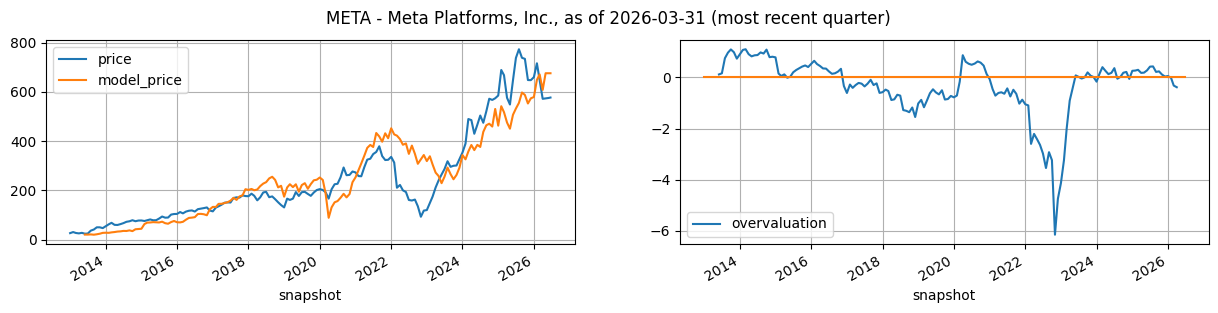

META(0001326801) model_price = 2.695387 * (0.514546 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +12.165166


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,366.021,148.778,115.8,716.50,0.514546,1.699207,236.324702,2.695387,12.165166,649.151698,-0.015526
2026-03-01,2025-12-31,366.021,148.778,115.8,648.18,0.514546,1.769745,244.492953,2.695387,12.165166,671.168294,-0.320955
2026-04-01,2025-12-31,366.021,148.778,115.8,572.13,0.514546,1.568282,221.163622,2.695387,12.165166,608.286719,-0.386378
2026-05-01,2026-03-31,395.250,151.569,124.0,NaN,0.514546,1.568282,246.272193,2.695387,12.165166,675.964035,NaN
2026-06-01,2026-03-31,395.250,151.569,124.0,NaN,0.514546,1.568282,246.272193,2.695387,12.165166,675.964035,NaN
2026-06-20,2026-03-31,395.250,151.569,124.0,577.30,0.514546,1.568282,246.272193,2.695387,12.165166,675.964035,NaN


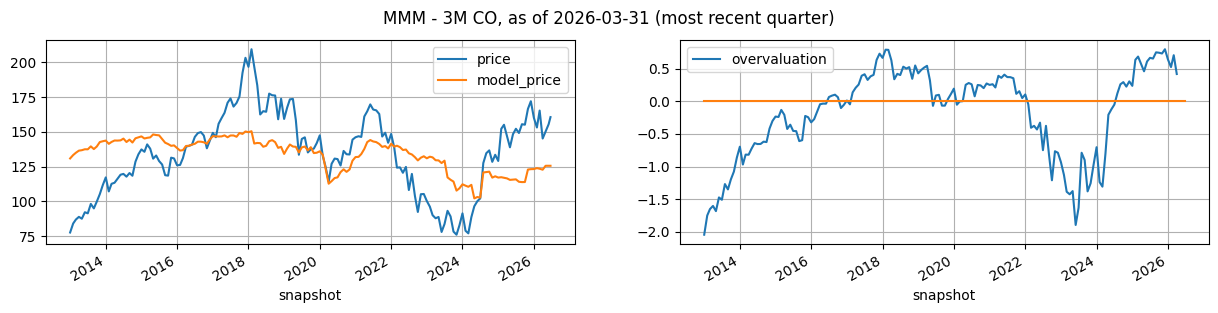

MMM(0000066740) model_price = 1.512070 * (0.006739 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +166.901532


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,37.611,32.983,2.541,153.16,0.006739,1.699207,-28.411841,1.51207,166.901532,123.940849,0.525351
2026-03-01,2025-12-31,37.733,33.031,2.306,165.32,0.006739,1.769745,-28.695673,1.51207,166.901532,123.511676,0.707465
2026-04-01,2025-12-31,37.733,33.031,2.306,145.23,0.006739,1.568282,-29.160245,1.51207,166.901532,122.809211,0.418653
2026-05-01,2026-03-31,35.436,32.173,2.959,NaN,0.006739,1.568282,-27.293637,1.51207,166.901532,125.631652,NaN
2026-06-01,2026-03-31,35.436,32.173,2.959,NaN,0.006739,1.568282,-27.293637,1.51207,166.901532,125.631652,NaN
2026-06-20,2026-03-31,35.436,32.173,2.959,160.63,0.006739,1.568282,-27.293637,1.51207,166.901532,125.631652,NaN


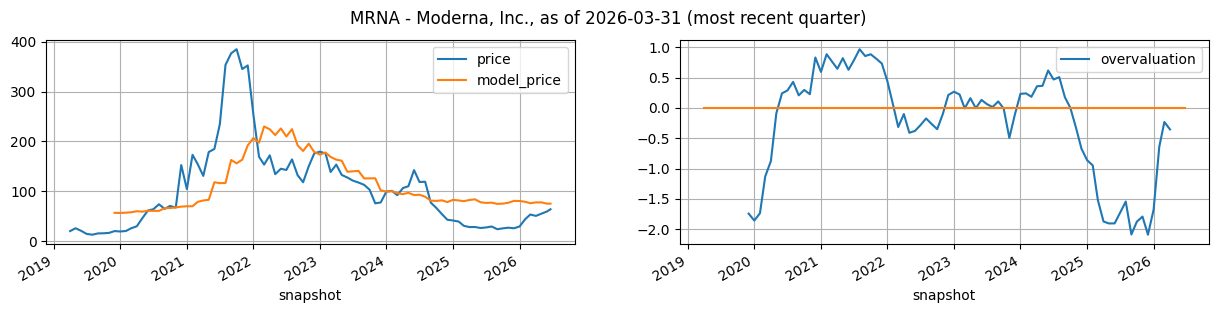

MRNA(0001682852) model_price = 4.569239 * (0.948564 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +54.699173


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,12.135,2.805,-1.978,44.07,0.948564,1.699207,5.344787,4.569239,54.699173,79.120786,-0.643036
2026-03-01,2025-12-31,12.338,3.688,-1.873,53.57,0.948564,1.769745,4.700646,4.569239,54.699173,76.177548,-0.232768
2026-04-01,2025-12-31,12.338,3.688,-1.873,50.80,0.948564,1.568282,5.077985,4.569239,54.699173,77.901700,-0.355279
2026-05-01,2025-12-31,12.338,3.688,-1.873,NaN,0.948564,1.568282,5.077985,4.569239,54.699173,77.901700,NaN
2026-06-01,2026-03-31,11.488,4.080,-1.466,NaN,0.948564,1.568282,4.517996,4.569239,54.699173,75.342980,NaN
2026-06-20,2026-03-31,11.488,4.080,-1.466,64.10,0.948564,1.568282,4.517996,4.569239,54.699173,75.342980,NaN


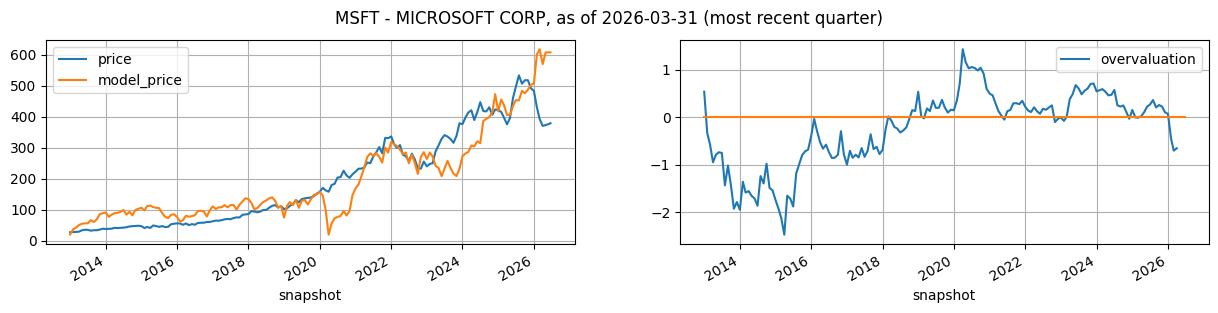

MSFT(0000789019) model_price = 1.485380 * (0.547008 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +63.026229


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,665.302,274.427,160.506,430.29,0.547008,1.699207,362.231233,1.48538,63.026229,601.077314,-0.444709
2026-03-01,2025-12-31,665.302,274.427,160.506,392.74,0.547008,1.769745,373.552936,1.48538,63.026229,617.894347,-0.703320
2026-04-01,2025-12-31,665.302,274.427,160.506,370.17,0.547008,1.568282,341.217033,1.48538,63.026229,569.863238,-0.653722
2026-05-01,2026-03-31,694.228,279.861,170.141,NaN,0.547008,1.568282,366.716178,1.48538,63.026229,607.739162,NaN
2026-06-01,2026-03-31,694.228,279.861,170.141,NaN,0.547008,1.568282,366.716178,1.48538,63.026229,607.739162,NaN
2026-06-20,2026-03-31,694.228,279.861,170.141,379.05,0.547008,1.568282,366.716178,1.48538,63.026229,607.739162,NaN


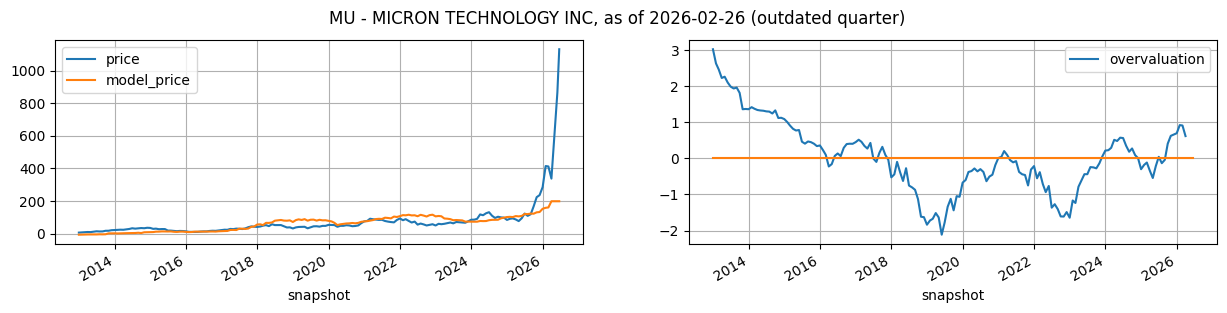

MU(0000723125) model_price = 1.459787 * (1.286906 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -19.648885


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-27,85.971,27.165,22.692,414.88,1.286906,1.699207,122.030044,1.459787,-19.648885,158.489043,0.921256
2026-03-01,2025-11-27,85.971,27.165,22.692,412.37,1.286906,1.769745,123.630682,1.459787,-19.648885,160.825635,0.909464
2026-04-01,2026-02-26,101.509,29.050,30.653,337.84,1.286906,1.568282,149.655149,1.459787,-19.648885,198.815826,0.616581
2026-05-01,2026-02-26,101.509,29.050,30.653,NaN,1.286906,1.568282,149.655149,1.459787,-19.648885,198.815826,NaN
2026-06-01,2026-02-26,101.509,29.050,30.653,NaN,1.286906,1.568282,149.655149,1.459787,-19.648885,198.815826,NaN
2026-06-20,2026-02-26,101.509,29.050,30.653,1132.01,1.286906,1.568282,149.655149,1.459787,-19.648885,198.815826,NaN


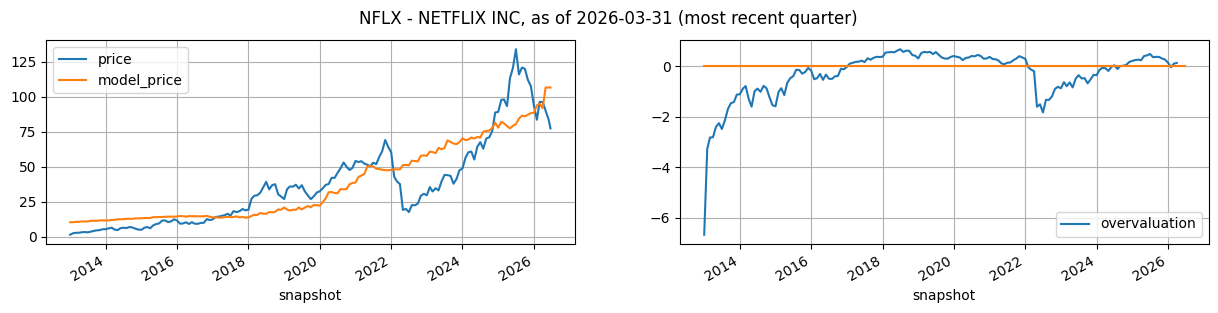

NFLX(0001065280) model_price = 1.548273 * (1.206888 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +8.107584


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,55.596993,28.981505,10.149273,83.49,1.206888,1.699207,55.363553,1.548273,8.107584,93.825487,-0.032873
2026-03-01,2025-12-31,55.596993,28.981505,10.149273,96.24,1.206888,1.769745,56.079458,1.548273,8.107584,94.933904,0.104665
2026-04-01,2025-12-31,55.596993,28.981505,10.149273,96.15,1.206888,1.568282,54.034762,1.548273,8.107584,91.768156,0.136707
2026-05-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.206888,1.568282,63.589066,1.548273,8.107584,106.560829,NaN
2026-06-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.206888,1.568282,63.589066,1.548273,8.107584,106.560829,NaN
2026-06-20,2026-03-31,61.015914,29.889515,12.650279,77.33,1.206888,1.568282,63.589066,1.548273,8.107584,106.560829,NaN


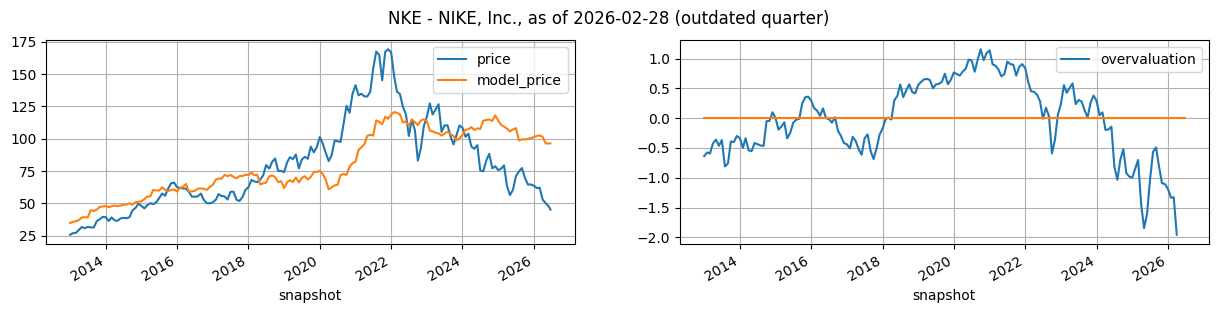

NKE(0000320187) model_price = 1.712171 * (2.185251 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -7.476231


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-30,37.787,23.702,3.056,61.810,2.185251,1.699207,64.064865,1.712171,-7.476231,102.213757,-1.336044
2026-03-01,2025-11-30,37.787,23.702,3.056,62.180,2.185251,1.769745,64.280428,1.712171,-7.476231,102.582837,-1.327034
2026-04-01,2025-11-30,37.787,23.702,3.056,52.820,2.185251,1.568282,63.664759,1.712171,-7.476231,101.528707,-1.955577
2026-05-01,2026-02-28,37.064,22.974,1.694,NaN,2.185251,1.568282,60.676822,1.712171,-7.476231,96.412849,NaN
2026-06-01,2026-02-28,37.064,22.974,1.694,NaN,2.185251,1.568282,60.676822,1.712171,-7.476231,96.412849,NaN
2026-06-20,2026-02-28,37.064,22.974,1.694,45.195,2.185251,1.568282,60.676822,1.712171,-7.476231,96.412849,NaN


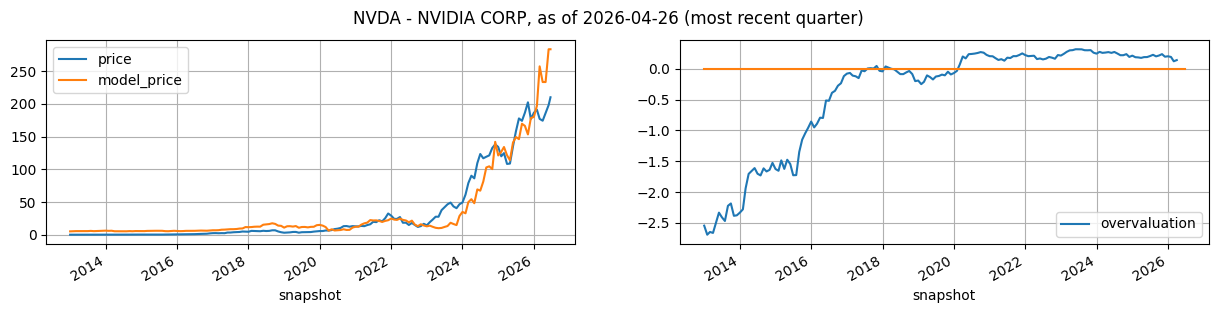

NVDA(0001045810) model_price = 1.156680 * (0.414283 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +5.295106


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-26,161.148,42.251,83.159,191.13,0.414283,1.699207,165.814191,1.15668,5.295106,197.089050,0.189919
2026-03-01,2026-01-25,206.803,49.510,102.718,177.19,0.414283,1.769745,217.949537,1.15668,5.295106,257.392958,0.119742
2026-04-01,2026-01-25,206.803,49.510,102.718,174.40,0.414283,1.568282,197.255735,1.15668,5.295106,233.456853,0.138726
2026-05-01,2026-01-25,206.803,49.510,102.718,NaN,0.414283,1.568282,197.255735,1.15668,5.295106,233.456853,NaN
2026-06-01,2026-04-26,259.474,64.000,125.648,NaN,0.414283,1.568282,240.547134,1.15668,5.295106,283.531146,NaN
2026-06-20,2026-04-26,259.474,64.000,125.648,210.20,0.414283,1.568282,240.547134,1.15668,5.295106,283.531146,NaN


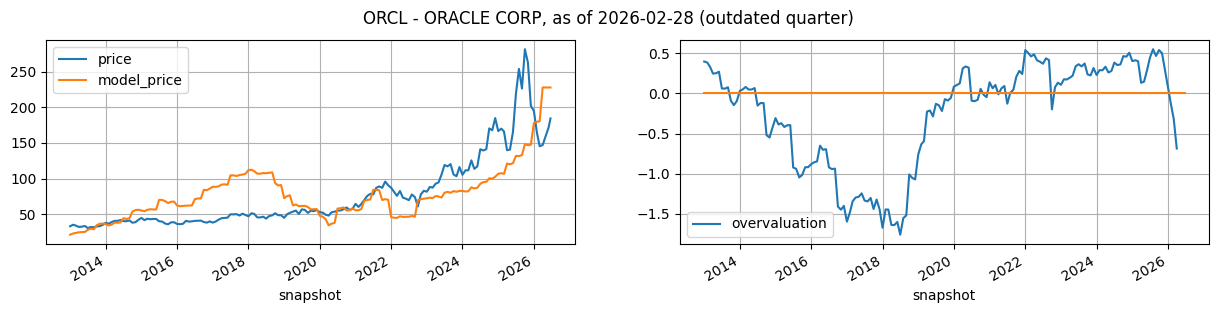

ORCL(0001341439) model_price = 0.436002 * (3.549338 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -77.745184


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-30,204.984,175.033,22.296,164.58,3.549338,1.699207,590.409993,0.436002,-77.745184,179.674676,-0.138221
2026-03-01,2025-11-30,204.984,175.033,22.296,145.40,3.549338,1.769745,591.982699,0.436002,-77.745184,180.360378,-0.317437
2026-04-01,2026-02-28,245.240,206.745,23.514,147.11,3.549338,1.568282,700.571209,0.436002,-77.745184,227.705172,-0.687872
2026-05-01,2026-02-28,245.240,206.745,23.514,NaN,3.549338,1.568282,700.571209,0.436002,-77.745184,227.705172,NaN
2026-06-01,2026-02-28,245.240,206.745,23.514,NaN,3.549338,1.568282,700.571209,0.436002,-77.745184,227.705172,NaN
2026-06-20,2026-02-28,245.240,206.745,23.514,184.33,3.549338,1.568282,700.571209,0.436002,-77.745184,227.705172,NaN


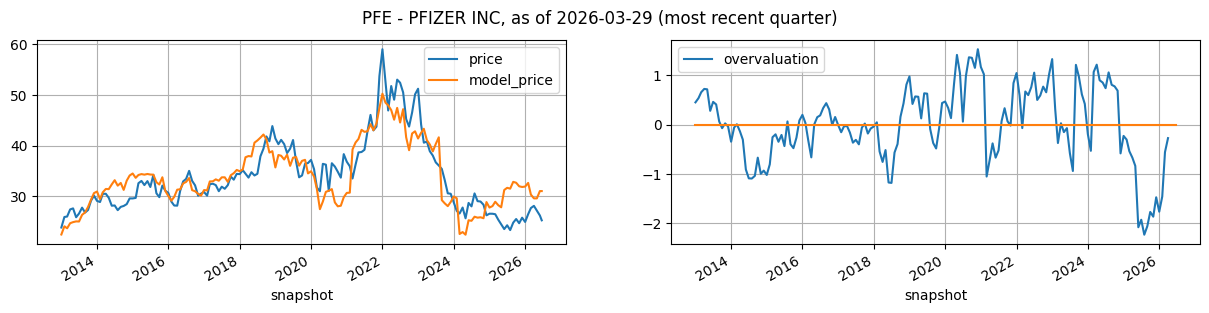

PFE(0000078003) model_price = 0.316441 * (0.071183 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +57.568799


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-28,208.731,115.930,13.077,26.44,0.071183,1.699207,-78.851323,0.316441,57.568799,32.617041,-1.455022
2026-03-01,2025-12-31,208.160,121.684,11.704,27.65,0.071183,1.769745,-86.153408,0.316441,57.568799,30.306365,-0.554897
2026-04-01,2025-12-31,208.160,121.684,11.704,28.08,0.071183,1.568282,-88.511323,0.316441,57.568799,29.560225,-0.271181
2026-05-01,2025-12-31,208.160,121.684,11.704,NaN,0.071183,1.568282,-88.511323,0.316441,57.568799,29.560225,NaN
2026-06-01,2026-03-29,207.618,117.517,11.984,NaN,0.071183,1.568282,-83.943785,0.316441,57.568799,31.005580,NaN
2026-06-20,2026-03-29,207.618,117.517,11.984,25.22,0.071183,1.568282,-83.943785,0.316441,57.568799,31.005580,NaN


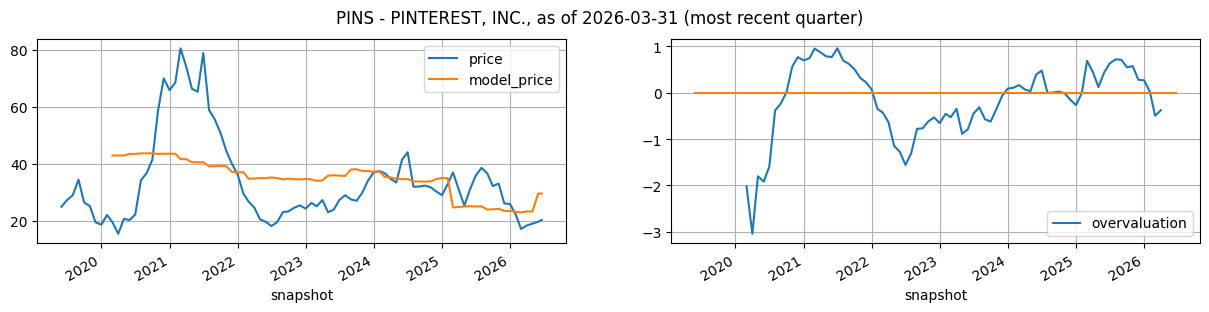

PINS(0001506293) model_price = -1.365598 * (4.116811 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +55.884649


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,5.515410,0.690442,1.147046,22.13,4.11681,1.699207,23.964523,-1.365598,55.884649,23.158740,0.018351
2026-03-01,2025-12-31,5.492132,0.746894,1.284264,17.13,4.11681,1.769745,24.135991,-1.365598,55.884649,22.924584,-0.496335
2026-04-01,2025-12-31,5.492132,0.746894,1.284264,18.34,4.11681,1.568282,23.877260,-1.365598,55.884649,23.277906,-0.374574
2026-05-01,2025-12-31,5.492132,0.746894,1.284264,NaN,4.11681,1.568282,23.877260,-1.365598,55.884649,23.277906,NaN
2026-06-01,2026-03-31,4.645279,1.794695,1.248581,NaN,4.11681,1.568282,19.287165,-1.365598,55.884649,29.546132,NaN
2026-06-20,2026-03-31,4.645279,1.794695,1.248581,20.29,4.11681,1.568282,19.287165,-1.365598,55.884649,29.546132,NaN


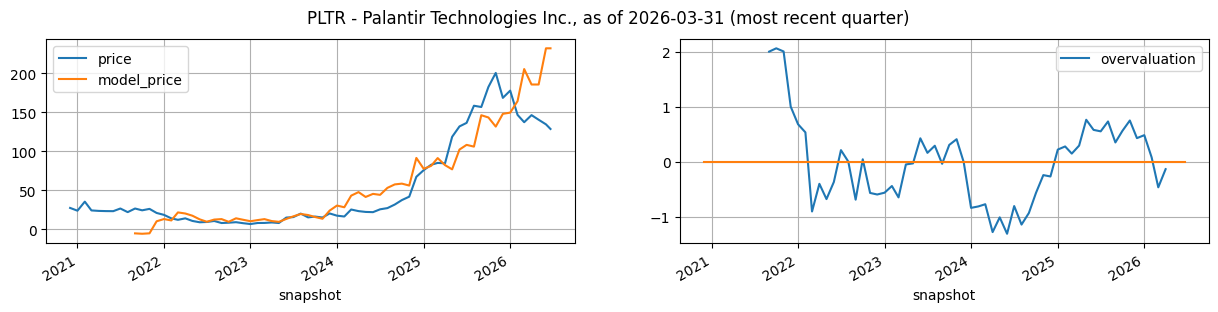

PLTR(0001321655) model_price = 46.148877 * (0.246449 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -0.276598


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,8.113960,1.523503,1.817505,146.59,0.246449,1.699207,3.564491,46.148877,-0.276598,164.220682,0.081636
2026-03-01,2025-12-31,8.900392,1.513124,2.134473,137.19,0.246449,1.769745,4.457841,46.148877,-0.276598,205.447743,-0.462585
2026-04-01,2025-12-31,8.900392,1.513124,2.134473,146.28,0.246449,1.568282,4.027825,46.148877,-0.276598,185.602998,-0.132648
2026-05-01,2025-12-31,8.900392,1.513124,2.134473,NaN,0.246449,1.568282,4.027825,46.148877,-0.276598,185.602998,NaN
2026-06-01,2026-03-31,10.199183,1.749520,2.723375,NaN,0.246449,1.568282,5.035079,46.148877,-0.276598,232.086655,NaN
2026-06-20,2026-03-31,10.199183,1.749520,2.723375,128.49,0.246449,1.568282,5.035079,46.148877,-0.276598,232.086655,NaN


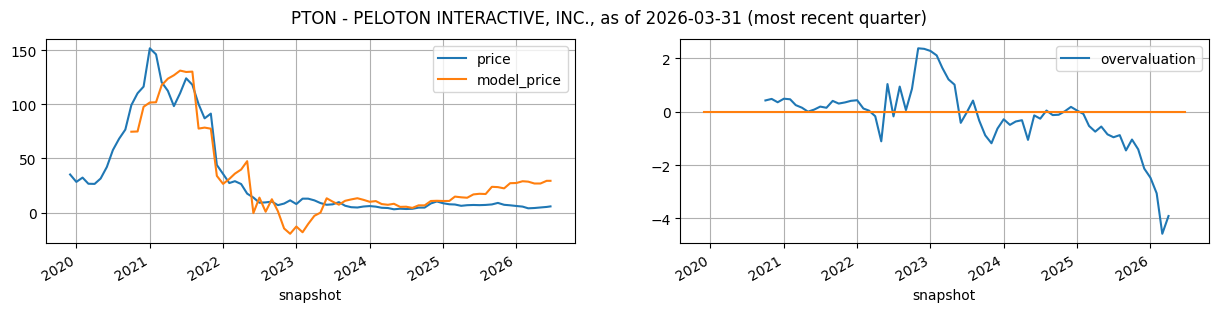

PTON(0001639825) model_price = 23.780987 * (1.463669 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.520611


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,2.1701,2.5171,0.3924,5.590,1.463669,1.699207,1.325977,23.780987,-2.520611,29.012439,-3.059568
2026-03-01,2025-12-31,2.1646,2.4913,0.3576,4.020,1.463669,1.769745,1.309819,23.780987,-2.520611,28.628177,-4.574596
2026-04-01,2025-12-31,2.1646,2.4913,0.3576,4.290,1.463669,1.568282,1.237776,23.780987,-2.520611,26.914926,-3.909744
2026-05-01,2025-12-31,2.1646,2.4913,0.3576,NaN,1.463669,1.568282,1.237776,23.780987,-2.520611,26.914926,NaN
2026-06-01,2026-03-31,2.0174,2.2593,0.4136,NaN,1.463669,1.568282,1.342148,23.780987,-2.520611,29.396988,NaN
2026-06-20,2026-03-31,2.0174,2.2593,0.4136,5.785,1.463669,1.568282,1.342148,23.780987,-2.520611,29.396988,NaN


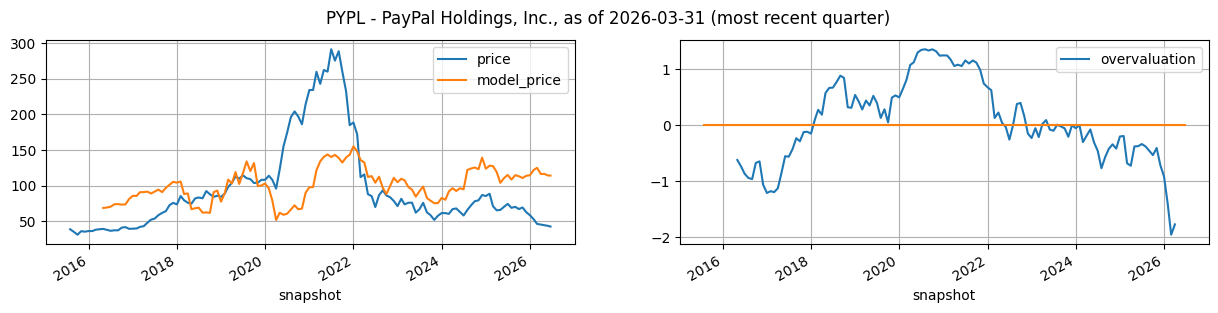

PYPL(0001633917) model_price = 6.642065 * (0.841101 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -0.435052


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,79.801,59.603,6.426,52.69,0.841101,1.699207,18.436824,6.642065,-0.435052,122.023532,-1.415671
2026-03-01,2025-12-31,80.173,59.917,6.416,46.21,0.841101,1.769745,18.871290,6.642065,-0.435052,124.909287,-1.958958
2026-04-01,2025-12-31,80.173,59.917,6.416,45.23,0.841101,1.568282,17.578709,6.642065,-0.435052,116.323874,-1.774801
2026-05-01,2025-12-31,80.173,59.917,6.416,NaN,0.841101,1.568282,17.578709,6.642065,-0.435052,116.323874,NaN
2026-06-01,2026-03-31,80.546,60.522,6.390,NaN,0.841101,1.568282,17.246664,6.642065,-0.435052,114.118412,NaN
2026-06-20,2026-03-31,80.546,60.522,6.390,42.48,0.841101,1.568282,17.246664,6.642065,-0.435052,114.118412,NaN


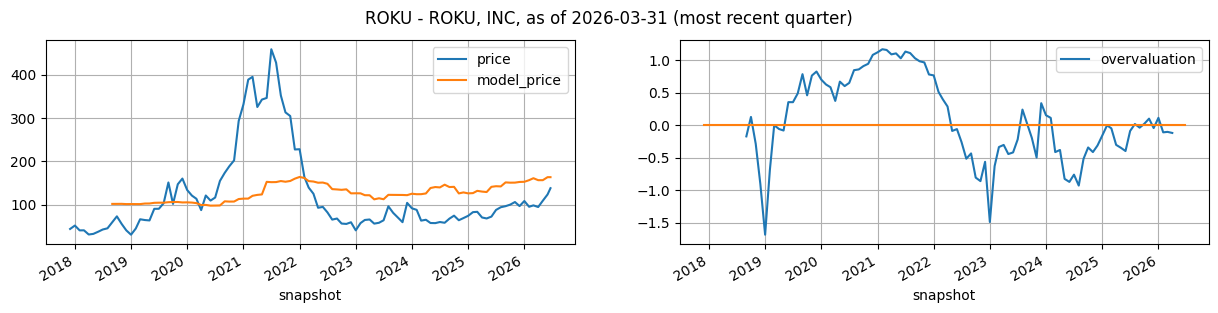

ROKU(0001428439) model_price = 46.755857 * (0.496327 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +101.310879


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,4.397285,1.772199,0.455360,95.20,0.496327,1.699207,1.184045,46.755857,101.310879,156.671922,-0.108965
2026-03-01,2025-12-31,4.433483,1.775538,0.483718,98.41,0.496327,1.769745,1.280979,46.755857,101.310879,161.204129,-0.101752
2026-04-01,2025-12-31,4.433483,1.775538,0.483718,94.62,0.496327,1.568282,1.183528,46.755857,101.310879,156.647727,-0.118264
2026-05-01,2025-12-31,4.433483,1.775538,0.483718,NaN,0.496327,1.568282,1.183528,46.755857,101.310879,156.647727,NaN
2026-06-01,2026-03-31,4.352634,1.681570,0.544126,NaN,0.496327,1.568282,1.332105,46.755857,101.310879,163.594583,NaN
2026-06-20,2026-03-31,4.352634,1.681570,0.544126,138.15,0.496327,1.568282,1.332105,46.755857,101.310879,163.594583,NaN


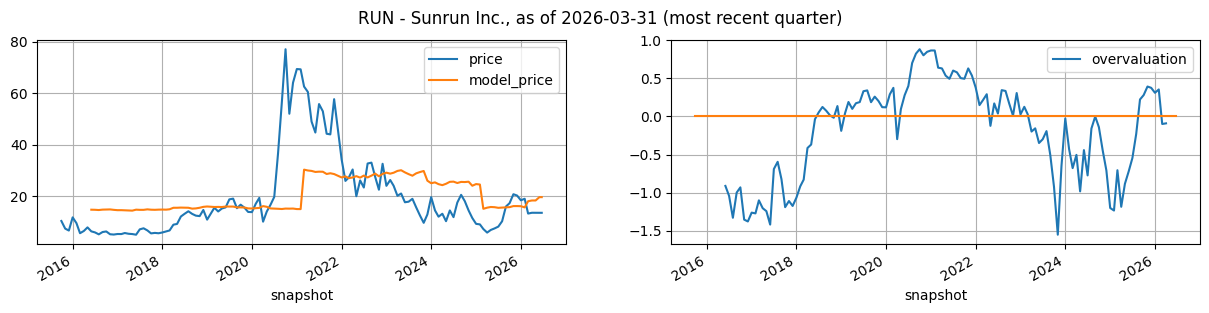

RUN(0001469367) model_price = 3.403074 * (0.951308 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.666994


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,22.225482,19.241580,-0.776747,19.00,0.951308,1.699207,0.581846,3.403074,13.666994,15.647061,0.355408
2026-03-01,2025-12-31,22.610596,19.478112,-0.421440,13.25,0.951308,1.769745,1.285689,3.403074,13.666994,18.042290,-0.098611
2026-04-01,2025-12-31,22.610596,19.478112,-0.421440,13.56,0.951308,1.568282,1.370594,3.403074,13.666994,18.331226,-0.090324
2026-05-01,2025-12-31,22.610596,19.478112,-0.421440,NaN,0.951308,1.568282,1.370594,3.403074,13.666994,18.331226,NaN
2026-06-01,2026-03-31,22.765093,19.424339,-0.306611,NaN,0.951308,1.568282,1.751425,3.403074,13.666994,19.627224,NaN
2026-06-20,2026-03-31,22.765093,19.424339,-0.306611,13.54,0.951308,1.568282,1.751425,3.403074,13.666994,19.627224,NaN


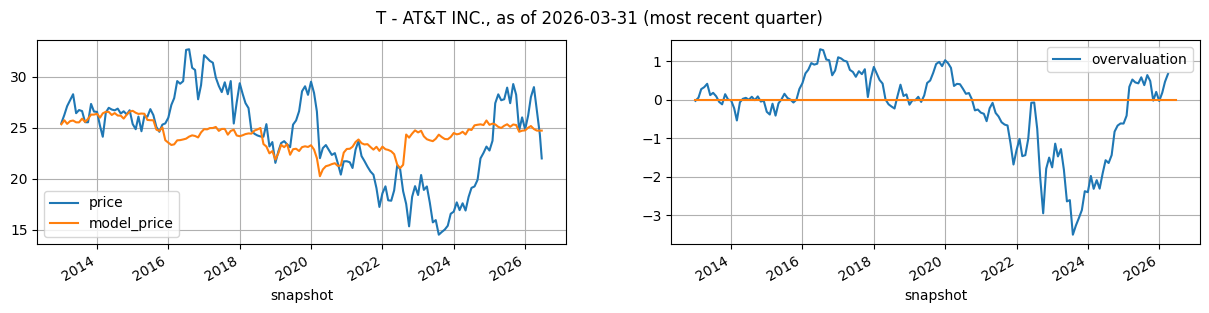

T(0000732717) model_price = 0.036332 * (0.018714 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.967549


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,423.213,296.458,40.860,26.210,0.018714,1.699207,-219.108228,0.036332,32.967549,25.006898,0.178836
2026-03-01,2025-12-31,420.198,293.707,40.284,28.010,0.018714,1.769745,-214.550860,0.036332,32.967549,25.172476,0.461399
2026-04-01,2025-12-31,420.198,293.707,40.284,28.990,0.018714,1.568282,-222.666566,0.036332,32.967549,24.877616,0.668222
2026-05-01,2026-03-31,421.188,295.569,38.792,NaN,0.018714,1.568282,-226.849916,0.036332,32.967549,24.725626,NaN
2026-06-01,2026-03-31,421.188,295.569,38.792,NaN,0.018714,1.568282,-226.849916,0.036332,32.967549,24.725626,NaN
2026-06-20,2026-03-31,421.188,295.569,38.792,21.995,0.018714,1.568282,-226.849916,0.036332,32.967549,24.725626,NaN


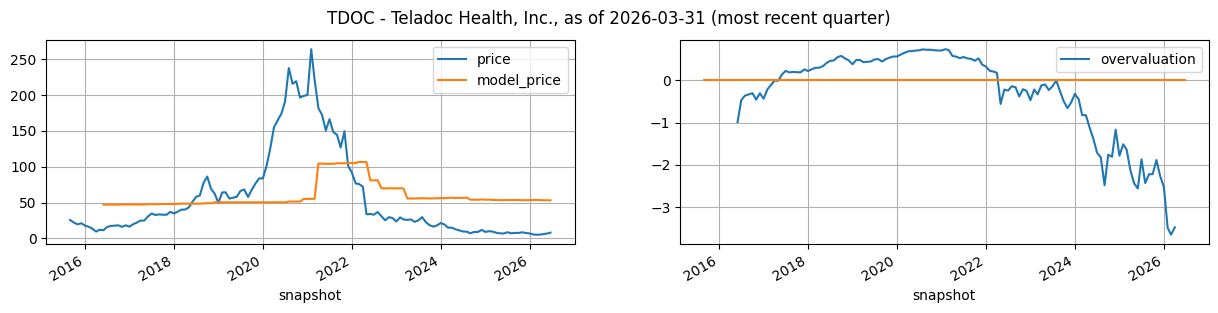

TDOC(0001477449) model_price = 3.773813 * (0.971112 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +46.765075


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,2.878547,1.486432,0.292517,5.45,0.971112,1.699207,1.806006,3.773813,46.765075,53.580606,-3.492850
2026-03-01,2025-12-31,2.858300,1.472594,0.294357,5.26,0.971112,1.769745,1.824072,3.773813,46.765075,53.648782,-3.654646
2026-04-01,2025-12-31,2.858300,1.472594,0.294357,5.45,0.971112,1.568282,1.764770,3.773813,46.765075,53.424988,-3.480299
2026-05-01,2026-03-31,2.807261,1.470945,0.287954,NaN,0.971112,1.568282,1.706813,3.773813,46.765075,53.206268,NaN
2026-06-01,2026-03-31,2.807261,1.470945,0.287954,NaN,0.971112,1.568282,1.706813,3.773813,46.765075,53.206268,NaN
2026-06-20,2026-03-31,2.807261,1.470945,0.287954,8.08,0.971112,1.568282,1.706813,3.773813,46.765075,53.206268,NaN


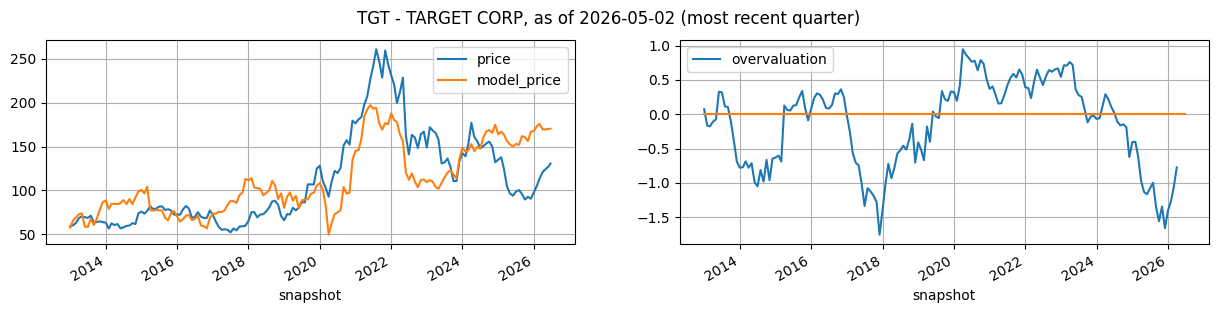

TGT(0000027419) model_price = 4.857943 * (1.510419 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -106.483296


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-01,59.991,44.490,6.774,105.47,1.510419,1.699207,57.631961,4.857943,-106.483296,173.489468,-1.264017
2026-03-01,2025-11-01,59.991,44.490,6.774,113.79,1.510419,1.769745,58.109783,4.857943,-106.483296,175.810698,-1.065421
2026-04-01,2026-01-31,59.490,43.325,6.562,121.20,1.510419,1.568282,56.820882,4.857943,-106.483296,169.549290,-0.774854
2026-05-01,2026-01-31,59.490,43.325,6.562,NaN,1.510419,1.568282,56.820882,4.857943,-106.483296,169.549290,NaN
2026-06-01,2026-05-02,58.010,41.615,7.003,NaN,1.510419,1.568282,56.987074,4.857943,-106.483296,170.356645,NaN
2026-06-20,2026-05-02,58.010,41.615,7.003,130.71,1.510419,1.568282,56.987074,4.857943,-106.483296,170.356645,NaN


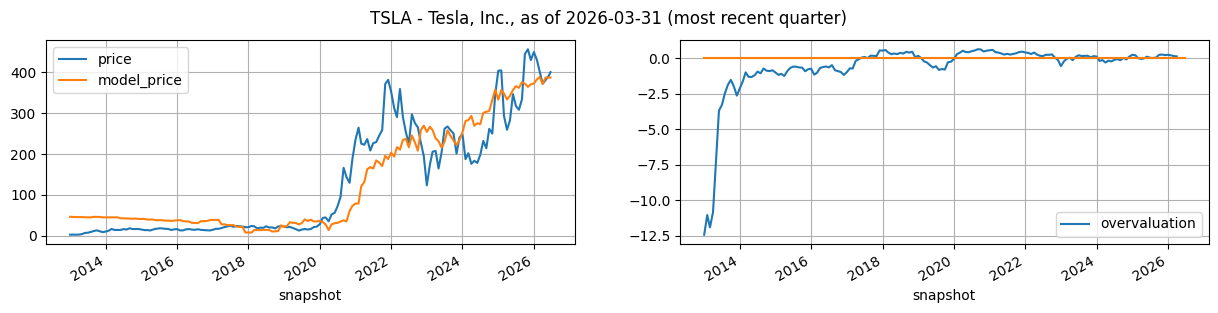

TSLA(0001318605) model_price = 5.635242 * (0.656019 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.730231


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,137.806,55.669,14.747,430.41,0.656019,1.699207,59.792557,5.635242,45.730231,382.675746,0.203422
2026-03-01,2025-12-31,137.806,55.669,14.747,402.51,0.656019,1.769745,60.832775,5.635242,45.730231,388.537623,0.154122
2026-04-01,2025-12-31,137.806,55.669,14.747,371.75,0.656019,1.568282,57.861811,5.635242,45.730231,371.795522,0.131581
2026-05-01,2026-03-31,143.724,59.608,16.528,NaN,0.656019,1.568282,60.598242,5.635242,45.730231,387.215973,NaN
2026-06-01,2026-03-31,143.724,59.608,16.528,NaN,0.656019,1.568282,60.598242,5.635242,45.730231,387.215973,NaN
2026-06-20,2026-03-31,143.724,59.608,16.528,400.50,0.656019,1.568282,60.598242,5.635242,45.730231,387.215973,NaN


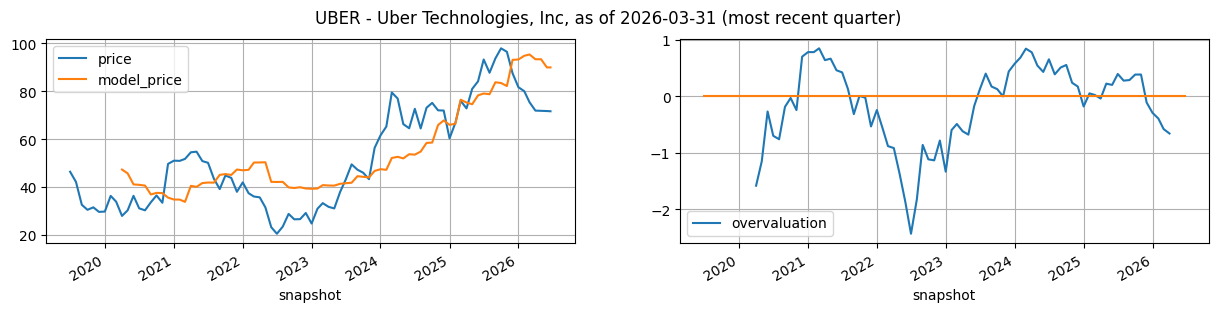

UBER(0001543151) model_price = 0.981040 * (1.640501 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +12.495621


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,63.344,35.210,8.966,80.05,1.640501,1.699207,83.941002,0.98104,12.495621,94.845080,-0.392004
2026-03-01,2025-12-31,61.802,34.761,10.099,75.42,1.640501,1.769745,84.497910,0.98104,12.495621,95.391429,-0.579011
2026-04-01,2025-12-31,61.802,34.761,10.099,71.93,1.640501,1.568282,82.463343,0.98104,12.495621,93.395437,-0.657617
2026-05-01,2025-12-31,61.802,34.761,10.099,NaN,1.640501,1.568282,82.463343,0.98104,12.495621,93.395437,NaN
2026-06-01,2026-03-31,59.885,35.134,10.126,NaN,1.640501,1.568282,78.987845,0.98104,12.495621,89.985836,NaN
2026-06-20,2026-03-31,59.885,35.134,10.126,71.66,1.640501,1.568282,78.987845,0.98104,12.495621,89.985836,NaN


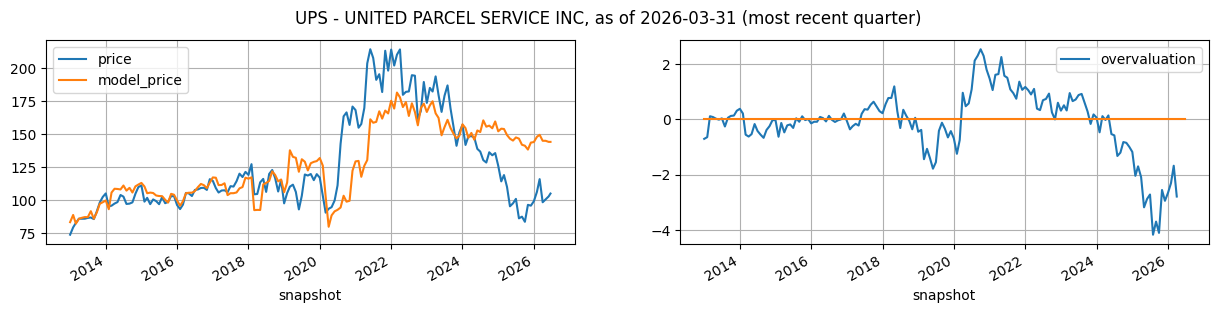

UPS(0001090727) model_price = 2.668230 * (0.763556 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +112.519719


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,71.392,55.569,8.463,106.22,0.763556,1.699207,13.323180,2.66823,112.519719,148.069032,-2.302946
2026-03-01,2025-12-31,73.090,56.863,8.450,115.96,0.763556,1.769745,13.899650,2.66823,112.519719,149.607189,-1.675367
2026-04-01,2025-12-31,73.090,56.863,8.450,98.38,0.763556,1.568282,12.197294,2.66823,112.519719,145.064911,-2.789862
2026-05-01,2025-12-31,73.090,56.863,8.450,NaN,0.763556,1.568282,12.197294,2.66823,112.519719,145.064911,NaN
2026-06-01,2026-03-31,71.809,56.046,8.356,NaN,0.763556,1.568282,11.888761,2.66823,112.519719,144.241672,NaN
2026-06-20,2026-03-31,71.809,56.046,8.356,105.00,0.763556,1.568282,11.888761,2.66823,112.519719,144.241672,NaN


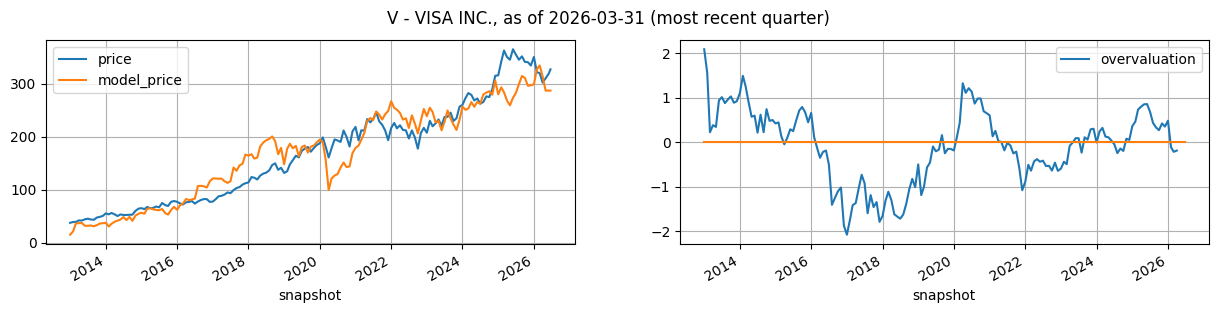

V(0001403161) model_price = 4.282509 * (1.234720 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -113.885970


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,96.814,58.037,24.443,321.83,1.234721,1.699207,103.034957,4.282509,-113.88597,327.362190,-0.113062
2026-03-01,2025-12-31,96.814,58.037,24.443,320.14,1.234721,1.769745,104.759107,4.282509,-113.88597,334.745877,-0.216103
2026-04-01,2025-12-31,96.814,58.037,24.443,302.24,1.234721,1.568282,99.834765,4.282509,-113.88597,313.657336,-0.187664
2026-05-01,2026-03-31,95.049,59.388,22.756,NaN,1.234721,1.568282,93.658791,4.282509,-113.88597,287.208669,NaN
2026-06-01,2026-03-31,95.049,59.388,22.756,NaN,1.234721,1.568282,93.658791,4.282509,-113.88597,287.208669,NaN
2026-06-20,2026-03-31,95.049,59.388,22.756,327.25,1.234721,1.568282,93.658791,4.282509,-113.88597,287.208669,NaN


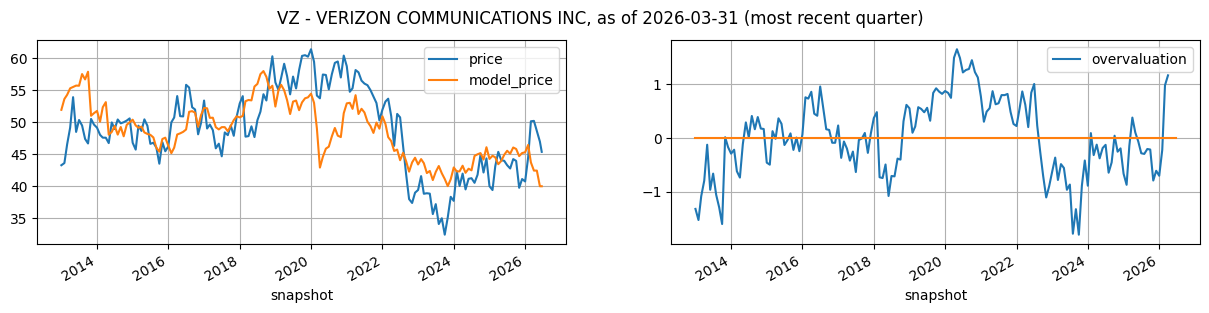

VZ(0000732712) model_price = 0.170926 * (0.007899 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +82.954200


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,388.331,281.986,38.455,44.52,0.007899,1.699207,-213.575575,0.170926,82.9542,46.448531,-0.222072
2026-03-01,2025-12-31,404.258,298.517,37.137,50.14,0.007899,1.769745,-229.600769,0.170926,82.9542,43.709404,0.983067
2026-04-01,2025-12-31,404.258,298.517,37.137,50.20,0.007899,1.568282,-237.082473,0.170926,82.9542,42.430585,1.169323
2026-05-01,2025-12-31,404.258,298.517,37.137,NaN,0.007899,1.568282,-237.082473,0.170926,82.9542,42.430585,NaN
2026-06-01,2026-03-31,417.882,313.260,37.339,NaN,0.007899,1.568282,-251.401064,0.170926,82.9542,39.983162,NaN
2026-06-20,2026-03-31,417.882,313.260,37.339,45.36,0.007899,1.568282,-251.401064,0.170926,82.9542,39.983162,NaN


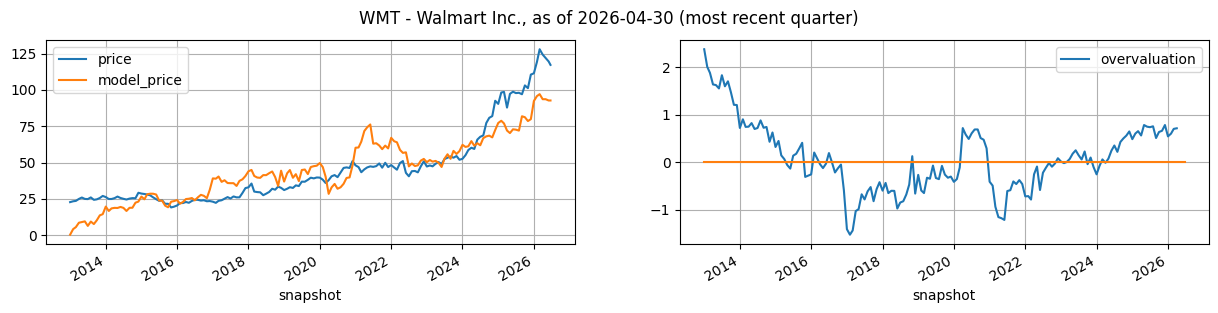

WMT(0000104169) model_price = 0.468135 * (1.903603 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -103.995470


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-31,288.655,192.561,40.977,119.14,1.903603,1.699207,426.552057,0.468135,-103.99547,95.688669,0.602096
2026-03-01,2025-10-31,288.655,192.561,40.977,127.95,1.903603,1.769745,429.442475,0.468135,-103.99547,97.041776,0.703066
2026-04-01,2026-01-31,284.668,185.051,41.565,124.28,1.903603,1.568282,422.029639,0.468135,-103.99547,93.571564,0.715541
2026-05-01,2026-01-31,284.668,185.051,41.565,NaN,1.903603,1.568282,422.029639,0.468135,-103.99547,93.571564,NaN
2026-06-01,2026-04-30,289.607,195.277,40.892,NaN,1.903603,1.568282,420.150082,0.468135,-103.99547,92.691677,NaN
2026-06-20,2026-04-30,289.607,195.277,40.892,117.18,1.903603,1.568282,420.150082,0.468135,-103.99547,92.691677,NaN


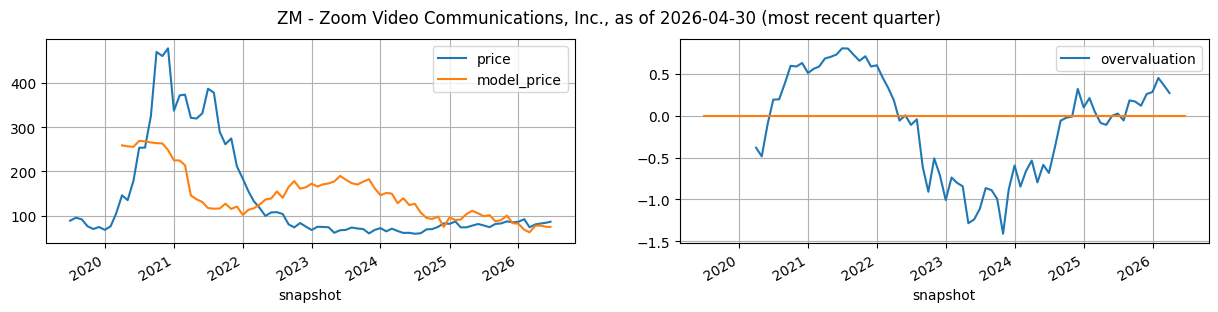

ZM(0001585521) model_price = -37.516857 * (0.316952 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +255.987308


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-31,11.390811,2.103971,2.059093,92.10,0.316952,1.699207,5.005192,-37.516857,255.987308,68.208229,0.452612
2026-03-01,2026-01-31,11.960416,2.152158,1.989048,73.94,0.316952,1.769745,5.158824,-37.516857,255.987308,62.444441,0.368432
2026-04-01,2026-01-31,11.960416,2.152158,1.989048,80.39,0.316952,1.568282,4.758106,-37.516857,255.987308,77.478125,0.271853
2026-05-01,2026-01-31,11.960416,2.152158,1.989048,NaN,0.316952,1.568282,4.758106,-37.516857,255.987308,77.478125,NaN
2026-06-01,2026-04-30,12.162017,2.190869,2.021397,NaN,0.316952,1.568282,4.834025,-37.516857,255.987308,74.629877,NaN
2026-06-20,2026-04-30,12.162017,2.190869,2.021397,86.41,0.316952,1.568282,4.834025,-37.516857,255.987308,74.629877,NaN


In [19]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    
    try:
        most_recent_price = recent_prices.loc[ticker]
        name = most_recent_price['name']
        most_recent_price = most_recent_price['price']
    except:
        name = ""
        most_recent_price = np.nan
        
    try:
        name = tickers.loc[cik]['name']
    except:
        pass

    df = df.reset_index().set_index('snapshot')
    df.iloc[-1,df.columns.get_loc('price')] = most_recent_price

    quarters_since_last_report = (datetime.today() - df['date'].max()) / timedelta(days=7) / 13
    caption = f"{ticker} - {name}"
    caption += f", as of {df['date'].max():%Y-%m-%d} ({"most recent" if quarters_since_last_report < 1 else "outdated"} quarter)"
    
    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(caption)
    fig.set_size_inches(15,5)
    df[['price','model_price']].interpolate().plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{}({}) model_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, cik, df['hype'].mean(), df['asmul'].mean(),
        "+" if df['bias'].mean() >= 0 else "", df['bias'].mean()
    ))

    # Display a few most recent records from the result set
    display(df.drop(columns=['cik','ticker']).tail(6))

for i in result[result.index.isin(sample_tickers, level='ticker')].groupby(by=['ticker','cik']):
    plot_ticker(i)
    display(HTML("<hr>"))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together, as shown below. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

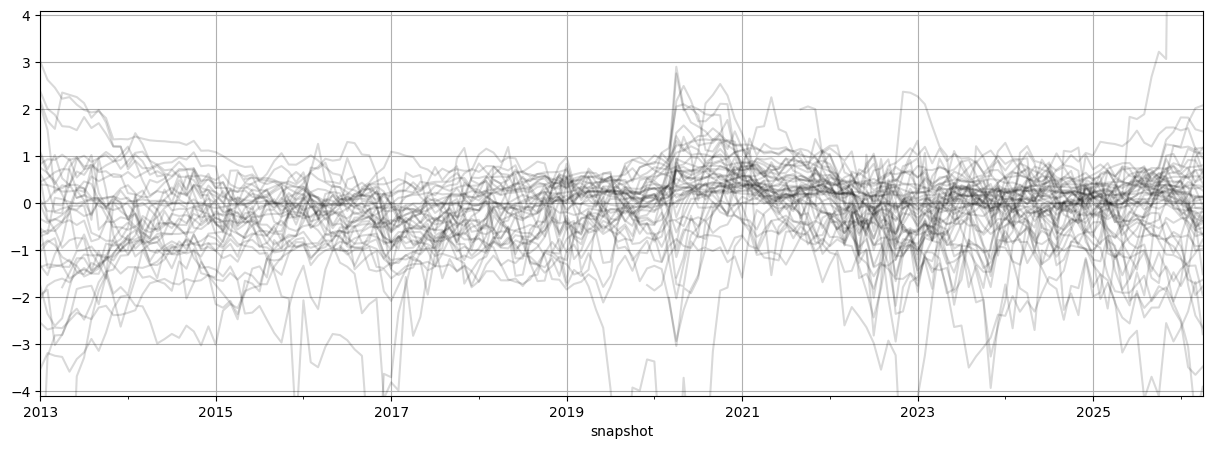

In [20]:
pd.pivot_table(result[result.index.isin(sample_tickers, level='ticker')],
               index='snapshot', columns='ticker', values='overvaluation').plot(
               grid=True, legend=False, c='black', alpha=0.15, figsize=(15,5),ylim=(-4.1,4.1))
plt.show()

In [21]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.